# Dimension Reduction Lab - Matrix Completion (Emidio Grillo & Luca Nudo)

This project addresses the **matrix completion** problem on rating data (MovieLens), aiming to reconstruct the full rating matrix from partially observed entries.  
We implement and compare three approaches: **SVP** (fixed-rank projection, non-convex), **SVT** (convex relaxation via singular-value soft-thresholding), and **ADMiRA** (greedy atom selection, akin to Matching Pursuit).  
Evaluation is performed using a **train/validation/test** split (60/20/20), with metrics computed **only on observed entries** as per the assignment specification, and **RMSE** reported as a supplementary interpretability metric.  
Results highlight a clear trade-off between **stability/guarantees** (SVT) and **accuracy/efficiency** (SVP, ADMiRA): SVT is more conservative but slower to converge and less competitive in relative error, while SVP and ADMiRA achieve better performance at lower rank.  
In particular, **r = 3** (ADMiRA) and **r = 4** (SVP) provide the best balance between accuracy and generalization, whereas larger ranks increase the train/val error gap — a clear overfitting signature.  
Operational recommendation: use **ADMiRA** as the default choice for best accuracy and lowest runtime; prefer **SVP** for simplicity and comparable performance; reserve **SVT** for settings where convexity guarantees and automatic rank selection are the main requirements.

## Introduction

This lab focuses on implementing and testing algorithms for the matrix completion problem, using the MovieLens dataset. The goal is to predict missing user ratings for movies by assuming the underlying rating matrix has low rank.

### Problem formulation
$
\hat{X}_r = \arg \min_{\text{rank}(X) \le r} \left\| X^S - Y^S \right\|_2^2
$


where \( $Y^S$ \) is the observed ratings matrix and \( S \) denotes the set of observed entries.

---

## Part 1: Dataset Exploration

Let's start by loading and exploring the MovieLens dataset.


In [1]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix, csr_matrix, load_npz, save_npz
from scipy.sparse.linalg import svds
import time

# Setting the plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# Loading the dataset
data = pd.read_csv('ratings.csv')

print("="*60)
print("DATASET EXPLORATION")
print("="*60)
print(f"\nDataset shape: {data.shape}")
print(f"\nFirst 10 rows:")
print(data.head(10))
print(f"\nDataset info:")
print(data.info())
print(f"\nDescriptive statistics:")
print(data.describe())

DATASET EXPLORATION

Dataset shape: (100836, 4)

First 10 rows:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
5       1       70     3.0  964982400
6       1      101     5.0  964980868
7       1      110     4.0  964982176
8       1      151     5.0  964984041
9       1      157     5.0  964984100

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Descriptive statistics:
              userId        movieId         rating     timestamp
co

In [ ]:
# Analyzing users, movies, and ratings
print("\n" + "="*60)
print("USER AND MOVIE ANALYSIS")
print("="*60)

n_users = data['userId'].nunique()
n_movies = data['movieId'].nunique()
n_ratings = len(data)

print(f"\nNumber of users: {n_users}")
print(f"Number of movies: {n_movies}")
print(f"Number of ratings: {n_ratings}")
print(f"\nFull matrix size: {n_users} × {n_movies} = {n_users * n_movies:,}")
print(f"Sparsity: {n_ratings / (n_users * n_movies) * 100:.2f}% (observed entries)")
print(f"Missing entries: {100 - n_ratings / (n_users * n_movies) * 100:.2f}%")

print(f"\nRatings per user distribution:")
ratings_per_user = data.groupby('userId').size()
print(f"  Mean: {ratings_per_user.mean():.2f}")
print(f"  Min: {ratings_per_user.min()}")
print(f"  Max: {ratings_per_user.max()}")

print(f"\nRatings per movie distribution:")
ratings_per_movie = data.groupby('movieId').size()
print(f"  Mean: {ratings_per_movie.mean():.2f}")
print(f"  Min: {ratings_per_movie.min()}")
print(f"  Max: {ratings_per_movie.max()}")

print(f"\nRating value distribution:")


USER AND MOVIE ANALYSIS

Number of users: 610
Number of movies: 9724
Number of ratings: 100836

Full matrix size: 610 × 9724 = 5,931,640
Sparsity: 1.70% (observed entries)
Missing entries: 98.30%

Ratings per user distribution:
  Mean: 165.30
  Min: 20
  Max: 2698

Ratings per movie distribution:
  Mean: 10.37
  Min: 1
  Max: 329

Rating value distribution:


## Fixed Train/Validation/Test Split (Used Throughout)

Before computing the singular values of $Y^S$, we perform a **single fixed split** of the observed ratings into train/validation/test sets (60/20/20), with a fixed random seed.

We compute the singular values **only on the training observed matrix** $Y^S_{\text{train}}$ in order to avoid any information leakage from validation/test ratings into the exploratory analysis of the spectrum.

The same split is then **reused unchanged** for SVP, SVT, and ADMiRA, so that all numerical comparisons are directly comparable. For this reason, the split procedure is **not repeated** in each algorithm section.


In [ ]:
# Train / Validation / Test split

np.random.seed(123)

n_ratings = len(data)
indices = np.random.permutation(n_ratings)

train_size = int(0.6 * n_ratings)
val_size   = int(0.2 * n_ratings)

train_data = data.iloc[indices[:train_size]].copy()
val_data   = data.iloc[indices[train_size:train_size + val_size]].copy()
test_data  = data.iloc[indices[train_size + val_size:]].copy()

print(f"Total ratings : {n_ratings}")
print(f"Train         : {len(train_data)}  ({len(train_data)/n_ratings*100:.1f}%)")
print(f"Validation    : {len(val_data)}  ({len(val_data)/n_ratings*100:.1f}%)")
print(f"Test          : {len(test_data)}  ({len(test_data)/n_ratings*100:.1f}%)")


Total ratings : 100836
Train         : 60501  (60.0%)
Validation    : 20167  (20.0%)
Test          : 20168  (20.0%)


In [ ]:
# Constructing the sparse matrix Y^S
print("\n" + "="*60)
print("CONSTRUCTING SPARSE MATRIX Y^S")
print("="*60)

# Mapping userId and movieId to 0-based indices
user_ids = data['userId'].unique()
movie_ids = data['movieId'].unique()

user_id_map = {uid: idx for idx, uid in enumerate(sorted(user_ids))}
movie_id_map = {mid: idx for idx, mid in enumerate(sorted(movie_ids))}

# Creating the mapped indices
row_indices = train_data['userId'].map(user_id_map).values
col_indices = train_data['movieId'].map(movie_id_map).values
ratings     = train_data['rating'].values

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"\nMatrix Y^S dimensions: {n_users} × {n_movies}")
print(f"Number of non-zero entries: {len(ratings)}")

# Creating sparse matrix in COO format, then converting it to CSR
Y_S_coo = coo_matrix((ratings, (row_indices, col_indices)), shape=(n_users, n_movies))
Y_S_train = Y_S_coo.tocsr()
print(f"Format: {type(Y_S_train)}")



CONSTRUCTING SPARSE MATRIX Y^S

Matrix Y^S dimensions: 610 × 9724
Number of non-zero entries: 60501
Format: <class 'scipy.sparse._csr.csr_matrix'>


## Dataset Summary

The MovieLens **ml-latest-small** dataset contains:

- 610 users  
- 9,724 movies  
- 100,836 ratings  
- Matrix sparsity: only ~1.7% of entries are observed  
- Rating scale: 0.5 to 5.0 stars (half-star increments)  

This extreme sparsity (98.3% missing data) makes this a challenging but realistic matrix completion problem.

---

# Preliminary Questions — Answers

---

# (i) Relationship with the course — sparse regression analogies

The matrix completion problem studied in this lab is closely related to the sparse linear regression framework covered in the course. In sparse regression we recover a high-dimensional **vector** under a sparsity constraint, while in matrix completion we recover a high-dimensional **matrix** under a low-rank constraint.

The analogy is:

- vector sparsity (few nonzero coefficients)  
  ↔ matrix low rank (few nonzero singular values)

Both lead to **non-convex combinatorial problems**:

- sparse regression → $\ell_0$ constraint  
- matrix completion → rank constraint  

Both admit:

- hard-thresholding / greedy methods  
- convex relaxations  
- proximal thresholding algorithms  

A rank-$r$ matrix admits the SVD expansion

$$
X = \sum_{i=1}^{r} \sigma_i u_i v_i^\top
$$

so it is “sparse” in the space of singular components, just like a sparse vector is sparse in coordinate space.

---

## Algorithmic analogies

### SVP ↔ Iterative Hard Thresholding (IHT)

SVP solves

$$
\min_X \|X^S - Y^S\|_F^2 \quad \text{s.t.} \quad \mathrm{rank}(X) \le r
$$

by alternating:

- a gradient step on the data-fit term
- a **hard projection** onto rank-$r$ matrices (truncate SVD to top $r$ singular values)

This directly mirrors Iterative Hard Thresholding in sparse regression:

- gradient step  
- keep top-$k$ coefficients (hard thresholding)

---

### SVT ↔ Convex relaxation (LASSO)

SVT replaces the rank constraint with nuclear norm regularization:

$$
\min_X \|X^S - Y^S\|_F^2 + \lambda \|X\|_*
$$

where

$$
\|X\|_* = \sum_i \sigma_i(X)
$$

is the nuclear norm (ℓ₁ norm of singular values).

The update performs:

- gradient step  
- **soft-thresholding of singular values**

This is exactly analogous to LASSO:

- ℓ₁ replaces ℓ₀  
- soft thresholding replaces hard thresholding  

So SVT is the convex relaxation counterpart of rank minimization.

---

### ADMiRA ↔ Matching Pursuit / Orthogonal Matching Pursuit

ADMiRA is a greedy algorithm that:

1. Computes the residual on observed entries  
2. Extracts leading singular directions of the residual  
3. Expands the active rank-1 component set  
4. Refits by least squares  
5. Prunes back to rank $r$

This is directly analogous to Matching Pursuit / OMP:

- select feature most correlated with residual  
- expand support  
- refit coefficients  
- prune if needed  

Here the “features” are rank-1 matrices $u v^\top$ instead of vector coordinates.

---

## Summary Table

| Matrix completion | Sparse regression analog | Core idea |
|------------------|--------------------------|-----------|
| SVP | Iterative Hard Thresholding | gradient + hard rank projection |
| SVT | LASSO / convex relaxation | nuclear norm + soft SV threshold |
| ADMiRA | Matching Pursuit / OMP | greedy rank-1 atom selection |

---

# (ii) Error behavior vs rank and overfitting

We study how the training error

$$
\|\hat{X}_r^S - Y^S\|_F^2
$$

behaves as the rank $r$ increases.

---

## Training error behavior

As $r$ increases, the constraint becomes less restrictive, so the model has more degrees of freedom. Therefore the **training error is non-increasing** with $r$.

In the extreme case

$$
r = \min(n,m)
$$

a matrix can interpolate all observed entries exactly, giving near-zero training error.

---

## Related phenomenon — Overfitting

This behavior is linked to **overfitting**.

- small $r$ → model too simple → underfitting  
- large $r$ → model too flexible → fits noise in observed entries  

So while training error decreases with $r$, the validation/test error typically follows a U-shaped curve:

- first decreases  
- then increases  

There exists an optimal rank $r^\*$ that balances fit and generalization.

---

## How to prevent overfitting

**Cross-validation**

- split observed ratings into train / validation / test  
- choose $r$ minimizing validation error  
- report final performance on test set  

**Regularization**

SVT uses nuclear norm regularization, which penalizes large numbers of singular values and favors lower-rank solutions.

**Early stopping**

Stop iterations when relative error on observed entries stops improving, as required by the lab stopping rule.


In [ ]:
# Compute singular values of Y^S (training-only)
print("="*60)
print("COMPUTING SINGULAR VALUES OF Y^S (TRAINING SET ONLY)")
print("="*60)

k = min(600, min(Y_S_train.shape) - 1)
print(f"\nComputing top {k} singular values...")

start_time = time.time()
U, singular_values, Vt = svds(Y_S_train, k=k)
elapsed_time = time.time() - start_time

# svds returns values in ascending order, reverse them
singular_values = singular_values[::-1]

print(f"\nFirst 20 singular values:")
for i, sv in enumerate(singular_values[:20], 1):
    print(f"  σ_{i}: {sv:.4f}")

print(f"\nSingular value statistics:")
print(f"  Maximum: {singular_values[0]:.4f}")
print(f"  Minimum (computed): {singular_values[-1]:.4f}")
print(f"  Median: {np.median(singular_values):.4f}")
print(f"  Mean: {np.mean(singular_values):.4f}")

# Compute explained variance
variance_explained = (singular_values**2) / np.sum(singular_values**2)
cumulative_variance = np.cumsum(variance_explained)

print(f"\nVariance explained by first singular values:")
for r in [1, 5, 10, 20, 50, 100, 200]:
    if r <= len(singular_values):
        print(f"  Rank {r}: {cumulative_variance[r-1]*100:.2f}%")


COMPUTING SINGULAR VALUES OF Y^S (TRAINING SET ONLY)

Computing top 600 singular values...

First 20 singular values:
  σ_1: 323.8284
  σ_2: 146.5914
  σ_3: 128.6258
  σ_4: 117.0635
  σ_5: 111.0129
  σ_6: 105.7554
  σ_7: 98.2614
  σ_8: 94.1506
  σ_9: 91.3890
  σ_10: 90.8981
  σ_11: 89.4556
  σ_12: 88.7087
  σ_13: 85.9087
  σ_14: 84.1904
  σ_15: 82.4092
  σ_16: 80.4559
  σ_17: 79.6579
  σ_18: 79.5100
  σ_19: 77.4423
  σ_20: 76.0536

Singular value statistics:
  Maximum: 323.8284
  Minimum (computed): 4.6752
  Median: 21.3103
  Mean: 28.1204

Variance explained by first singular values:
  Rank 1: 12.97%
  Rank 5: 20.90%
  Rank 10: 26.63%
  Rank 20: 35.04%
  Rank 50: 50.85%
  Rank 100: 67.38%
  Rank 200: 84.78%


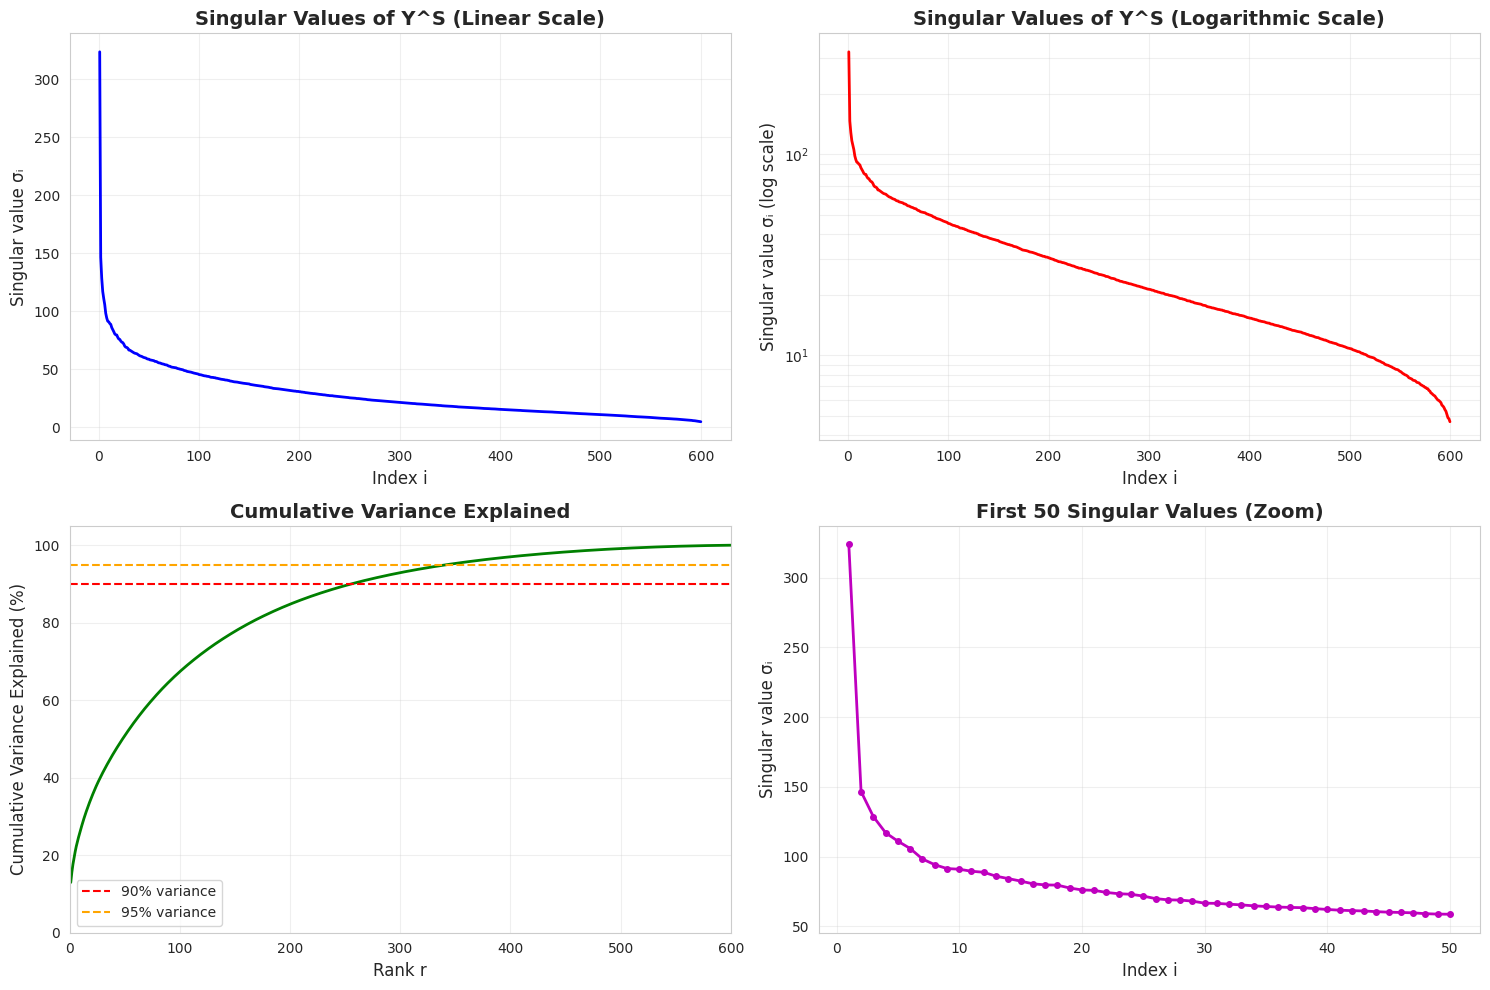


Plot saved as 'singular_values_analysis.png'


In [ ]:
# Creating comprehensive visualizations (plots)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Singular values (linear scale)
axes[0, 0].plot(range(1, len(singular_values)+1), singular_values, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Index i', fontsize=12)
axes[0, 0].set_ylabel('Singular value σᵢ', fontsize=12)
axes[0, 0].set_title('Singular Values of Y^S (Linear Scale)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Singular values (log scale)
axes[0, 1].semilogy(range(1, len(singular_values)+1), singular_values, 'r-', linewidth=2)
axes[0, 1].set_xlabel('Index i', fontsize=12)
axes[0, 1].set_ylabel('Singular value σᵢ (log scale)', fontsize=12)
axes[0, 1].set_title('Singular Values of Y^S (Logarithmic Scale)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, which='both')

# 3. Cumulative variance explained
axes[1, 0].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100, 'g-', linewidth=2)
axes[1, 0].axhline(y=90, color='r', linestyle='--', label='90% variance')
axes[1, 0].axhline(y=95, color='orange', linestyle='--', label='95% variance')
axes[1, 0].set_xlabel('Rank r', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
axes[1, 0].set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, len(cumulative_variance)])
axes[1, 0].set_ylim([0, 105])

# 4. Zooming on the first 50 singular values
axes[1, 1].plot(range(1, 51), singular_values[:50], 'mo-', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Index i', fontsize=12)
axes[1, 1].set_ylabel('Singular value σᵢ', fontsize=12)
axes[1, 1].set_title('First 50 Singular Values (Zoom)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('singular_values_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'singular_values_analysis.png'")

In [ ]:
# Find rank needed for various variance thresholds
print("\n" + "="*60)
print("RANK REQUIRED FOR DIFFERENT VARIANCE THRESHOLDS")
print("="*60)
for threshold in [0.80, 0.85, 0.90, 0.95, 0.99]:
    rank_needed = np.argmax(cumulative_variance >= threshold) + 1
    print(f"To explain {threshold*100:.0f}% of variance: rank r = {rank_needed}")

# Analyze decay of singular values
print("\n" + "="*60)
print("SINGULAR VALUE DECAY ANALYSIS")
print("="*60)
print("\nConsecutive ratios (first 20):")
for i in range(20):
    ratio = singular_values[i] / singular_values[i+1]
    print(f"  σ_{i+1}/σ_{i+2} = {ratio:.4f}")


RANK REQUIRED FOR DIFFERENT VARIANCE THRESHOLDS
To explain 80% of variance: rank r = 164
To explain 85% of variance: rank r = 202
To explain 90% of variance: rank r = 256
To explain 95% of variance: rank r = 343
To explain 99% of variance: rank r = 491

SINGULAR VALUE DECAY ANALYSIS

Consecutive ratios (first 20):
  σ_1/σ_2 = 2.2091
  σ_2/σ_3 = 1.1397
  σ_3/σ_4 = 1.0988
  σ_4/σ_5 = 1.0545
  σ_5/σ_6 = 1.0497
  σ_6/σ_7 = 1.0763
  σ_7/σ_8 = 1.0437
  σ_8/σ_9 = 1.0302
  σ_9/σ_10 = 1.0054
  σ_10/σ_11 = 1.0161
  σ_11/σ_12 = 1.0084
  σ_12/σ_13 = 1.0326
  σ_13/σ_14 = 1.0204
  σ_14/σ_15 = 1.0216
  σ_15/σ_16 = 1.0243
  σ_16/σ_17 = 1.0100
  σ_17/σ_18 = 1.0019
  σ_18/σ_19 = 1.0267
  σ_19/σ_20 = 1.0183
  σ_20/σ_21 = 1.0040


#  iii) Analysis of Results (Training Set Only)

The singular value analysis below is computed on the **training observed matrix** $Y^S_{\text{train}}$ only, in order to avoid any information leakage from validation/test ratings.

## Key Singular Values

- $\sigma_1 = 323.83$ (dominant, $\approx 2.21 \times$ larger than $\sigma_2$)  
- $\sigma_2 = 146.59$  
- $\sigma_3 = 128.63$  
- $\sigma_{10} = 90.90$  
- $\sigma_{20} = 76.05$  
- $\sigma_{600} = 4.68$  

---

## Variance Explained (from top-600 singular values)

- Rank 1: 12.97% of total variance  
- Rank 10: 26.63%  
- Rank 50: 50.85%  
- Rank 100: 67.38%  
- Rank 200: 84.78%  

From the cumulative curve, to capture:
- 90% of variance → we need $r \approx 256$ components  
- 95% of variance → we need $r \approx 343$ components  

(For reference: 80% at $r=164$, 85% at $r=202$, 99% at $r=491$.)

---

# What Does the Plot Tell Us?

## 1. Rapid Initial Decay
The first singular value is substantially larger than the second:
$$
\frac{\sigma_1}{\sigma_2} \approx 2.21.
$$
This suggests a strong dominant direction in the data, plausibly reflecting:
- global effects (e.g., overall movie popularity / baseline quality),
- user-level bias (some users consistently rate higher or lower).

---

## 2. Gradual Decay After the First Components
After the first few singular values, the decay becomes much more gradual: many consecutive ratios are close to 1 (typically $\approx 1.00$–$1.08$ in the early part of the spectrum).

This indicates:
- no sharp “elbow” after the first 10–20 components,
- structure spread across many dimensions,
- the spectrum alone is not sufficient to determine an “optimal” predictive rank.

---

## 3. Low-Rank Structure, But Not Ultra-Low
To explain 90% of the variance we need about $r \approx 256$ components out of a maximum possible rank of $610$:
$$
256 \ll 610.
$$
So a low-rank approximation is meaningful, but the dataset is **not** extremely low-dimensional: user preferences remain heterogeneous and multi-factor.

---

# Practical Implications

## For SVP (fixed rank $r$)
- Choosing $r$ too low risks underfitting (missing relevant latent factors).
- Choosing $r$ too high risks overfitting (capturing noise).

Given the gradual decay and the bias–variance tradeoff, a sensible strategy is to test a **wide but structured grid**, including small ranks
and then select $r$ by validation performance rather than “variance explained”.

---

## For SVT (soft thresholding $\lambda$)
The parameter $\lambda$ controls how many singular values survive the shrinkage:
- large $\lambda$ → stronger shrinkage → lower effective rank,
- small $\lambda$ → weaker shrinkage → higher effective rank.

$\lambda$ should be tuned via cross-validation, and the effective rank monitored as a diagnostic.

---

## For ADMiRA
ADMiRA builds the solution iteratively by selecting rank-1 atoms from the residual. The target rank $r$ still matters (hard constraint), but the greedy selection can improve interpretability and sometimes convergence behaviour compared to a single global projection.

---

# Conclusion for Question (iii)

From the training-only spectrum of $Y^S_{\text{train}}$ we conclude:
- the low-rank assumption is reasonable (variance concentrates in a subset of components),
- the structure is not ultra-low-rank (90% variance requires $\approx 256$ components),
- therefore, rank/regularisation parameters must be chosen by **cross-validation** to avoid overfitting.

## The "True" Rank of the Full Matrix $Y$
In principle,
$$
\mathrm{rank}(Y) = \min(610, 9724) = 610,
$$
but most of the energy concentrates in the first few hundred components, supporting low-rank matrix completion as a meaningful approximation.


# Part 3: Algorithm Implementation – SVP (Singular Value Projection)

## Overview
The **Singular Value Projection (SVP)** algorithm iteratively:

1. Corrects the current estimate to match the observed entries, and  
2. Projects the estimate onto the set of matrices with rank at most $r$.

It is analogous to **Iterative Hard Thresholding (IHT)** in sparse regression: each iteration applies a gradient-like correction followed by a **hard projection** onto a low-rank constraint.

---

## Pseudocode

**Algorithm 1 – Singular Value Projection (SVP)**

**Input:** observed entries $S$, observed matrix $Y^S$, target rank $r$  
**Initialize:** $X_0 = 0$

**While** stopping criterion not met **do**

$$
X_{t+\frac12} = X_t + (Y^S - X_t^S)
$$

$$
X_{t+1} = \text{SVD}_r(X_{t+\frac12})
$$

$$
t \gets t + 1
$$

**End while**

**Return:** $X_t$

> Note: `SVD_r(M)` denotes a truncated SVD keeping only the top-$r$ singular triplets.

---

## Error Measure and Stopping Criterion

The **relative error on observed entries** $S$ is

$$
\text{err}(X,Y) = \frac{\|X^S - Y^S\|_F}{\|Y^S\|_F}
= \sqrt{\frac{\sum_{(i,j)\in S} (X_{ij}-Y_{ij})^2}{\sum_{(i,j)\in S} (Y_{ij})^2}}
$$

Stop the iteration when **either**:

- $\text{err}(X_t, Y) < \varepsilon$ (convergence), or  
- $\text{err}(X_{t+1}, Y) \ge \text{err}(X_t, Y)$ (no improvement)

> RMSE is used only as a supplementary interpretability metric.

---

## Key Features

- Hard rank constraint (non-convex)  
- IHT-style iteration: gradient step on $S$ + rank-$r$ projection  
- Requires specifying target rank $r$ (selected via validation)  
- Rank-$r$ projection implemented via truncated SVD (`svds`) returning top-$r$ singular triplets

---

## Step 1 – Data Preparation

We reuse the **fixed train/validation/test split** (60/20/20, fixed seed):

- Ensures comparability across SVP, SVT, and ADMiRA  
- Avoids data leakage and inconsistencies  
- Training-only spectrum analysis (Question iii) uses the same split


## Step 2 – Helper Functions
We build sparse observed matrices $Y^S$ in CSR format and compute the required error metrics on observed entries only.


In [ ]:
def create_sparse_matrix(df, user_id_map, movie_id_map, n_users, n_movies):
    """Build a CSR sparse matrix Y^S from a ratings DataFrame."""
    rows = df['userId'].map(user_id_map).values
    cols = df['movieId'].map(movie_id_map).values
    vals = df['rating'].values
    return csr_matrix(
        coo_matrix((vals, (rows, cols)), shape=(n_users, n_movies))
    )

def relative_error(X, Y_S):
    """
    Assignment metric (computed only on observed entries S):

        err(X,Y) = ||X^S - Y^S||_2 / ||Y^S||_2

    where ||·||_2 is the Euclidean norm of the vector of observed entries
    (equivalently, Frobenius norm restricted to S).
    """
    rows, cols = Y_S.nonzero()
    num = sum((X[r, c] - Y_S[r, c])**2 for r, c in zip(rows, cols))
    den = Y_S.multiply(Y_S).sum()
    return np.sqrt(num / den)

def rmse(X, Y_S):
    """Supplementary metric: RMSE on observed entries."""
    rows, cols = Y_S.nonzero()
    sq = [(X[r, c] - Y_S[r, c])**2 for r, c in zip(rows, cols)]
    return np.sqrt(np.mean(sq))


## Step 3 – Rank-$r$ Projection via Truncated SVD

To implement lines 4–5 of Algorithm 1, we compute a rank-$r$ approximation of $X_{t+\frac{1}{2}}$ using `svds`.  
Note that `svds` returns singular values in **ascending** order, hence we reverse them to obtain the standard descending ordering (largest first).


In [ ]:
def svd_rank_r(M, r):
    """
    Rank-r approximation using truncated SVD (top-r singular triplets).
    Note: svds returns singular values in ASCENDING order.
    """
    U, s, Vt = svds(M, k=r)
    U  = U[:, ::-1]
    s  = s[::-1]
    Vt = Vt[::-1, :]
    return U @ np.diag(s) @ Vt

## Step 4 – SVP Algorithm

We implement the update:
$$
X_{t+\frac{1}{2}} = X_t + \left(Y^S - X_t^S\right).
$$

In practice, this means: we **replace the observed entries** with their ground-truth ratings (enforcing agreement on $S$), while keeping the current predictions unchanged on the unobserved entries.  
We then project the resulting matrix onto the set of rank-$r$ matrices via the truncated SVD step.


In [ ]:
def SVP_algorithm(Y_S_train, Y_S_val, r, epsilon=1e-2, max_iter=100, verbose=True):
    """
    Singular Value Projection – Algorithm 1 (Meka et al., 2009).

    Stopping criterion (assignment specification):
      • err(X_t, Y) < epsilon          [convergence]
      • err(X_{t+1}, Y) > err(X_t, Y)  [no improvement]

    Parameters
    ----------
    Y_S_train : csr_matrix  – observed training ratings
    Y_S_val   : csr_matrix  – observed validation ratings
    r         : int         – target rank
    epsilon   : float       – convergence threshold (default 1e-2)
    max_iter  : int         – safety cap on iterations

    Returns
    -------
    X       : ndarray  – final predicted matrix
    history : dict     – err_train, err_val, time per iteration
    """
    n, m = Y_S_train.shape
    rows_tr, cols_tr = Y_S_train.nonzero()

    # Line 1 – initialise
    X = np.zeros((n, m))

    history = {'err_train': [], 'err_val': [], 'time': []}
    t0 = time.time()

    if verbose:
        print(f"SVP  r={r}  |  matrix {n}×{m}")
        print("-" * 55)

    for t in range(max_iter):                           # line 2

        # ── Line 3 ──────────────────────────────────────────────
        # X_{t+1/2} = X_t + (Y^S − X_t^S)
        # On observed positions: replaces X_t entry with true rating.
        # On unobserved positions: keeps X_t prediction unchanged.
        X_half = X.copy()
        for r_, c_ in zip(rows_tr, cols_tr):
            X_half[r_, c_] = Y_S_train[r_, c_]

        # ── Lines 4–5 ────────────────────────────────────────────
        # [U, Σ, V] = SVD_r(X_{t+1/2})  →  X_{t+1} = U Σ V^T
        X_new = svd_rank_r(X_half, r)

        err_train = relative_error(X_new, Y_S_train)
        err_val   = relative_error(X_new, Y_S_val)

        history['err_train'].append(err_train)
        history['err_val'].append(err_val)
        history['time'].append(time.time() - t0)

        if verbose and (t < 5 or t % 5 == 4):
            print(f"  iter {t+1:3d}  err_train={err_train:.5f}  "
                  f"err_val={err_val:.5f}  "
                  f"t={history['time'][-1]:.1f}s")

        # ── Line 6 ───────────────────────────────────────────────
        X = X_new  # t ← t + 1

        # ── Stopping criterion ───────────────────────────────────
        if err_train < epsilon:
            if verbose:
                print(f"\n  → Converged: err_train={err_train:.5f} < ε={epsilon}")
            break
        if len(history['err_train']) > 1 and err_train >= history['err_train'][-2]:
            if verbose:
                print(f"\n  → Stopped: no improvement at iter {t+1}")
            break

    if verbose:
        print("-" * 55)
        print(f"  Finished: {len(history['err_train'])} iters  "
              f"total time={history['time'][-1]:.1f}s")
        print(f"  Final err_train={history['err_train'][-1]:.4f}  "
              f"err_val={history['err_val'][-1]:.4f}")

    return X, history   # line 8

## Step 5 – Build Sparse Matrices

We create the sparse observed matrices $Y^S_{\text{train}}$, $Y^S_{\text{val}}$, and $Y^S_{\text{test}}$ from the **fixed** train/validation/test split.


In [ ]:
# ID mappings (built from the full dataset to cover all users/movies)
user_ids  = data['userId'].unique()
movie_ids = data['movieId'].unique()

user_id_map  = {u: i for i, u in enumerate(sorted(user_ids))}
movie_id_map = {m: i for i, m in enumerate(sorted(movie_ids))}

n_users  = len(user_ids)
n_movies = len(movie_ids)

print(f"Matrix dimensions: {n_users} × {n_movies}")

Y_S_train = create_sparse_matrix(train_data, user_id_map, movie_id_map, n_users, n_movies)
Y_S_val   = create_sparse_matrix(val_data,   user_id_map, movie_id_map, n_users, n_movies)
Y_S_test  = create_sparse_matrix(test_data,  user_id_map, movie_id_map, n_users, n_movies)

print(f"Non-zero entries  –  train: {Y_S_train.nnz}  "
      f"val: {Y_S_val.nnz}  test: {Y_S_test.nnz}")

Matrix dimensions: 610 × 9724
Non-zero entries  –  train: 60501  val: 20167  test: 20168


## Step 6 – Cross-Validation for Rank Selection in SVP

In this step we perform a focused cross-validation procedure to select the optimal target rank for the SVP (Singular Value Projection) algorithm.

Preliminary experiments with larger ranks showed limited validation improvements and signs of overfitting, while also increasing computational cost. For this reason, we restrict the search to a smaller and more stable range of candidate ranks:

r = 2, 3, 4, 5

For each candidate rank, we run SVP on the training set and monitor performance on the validation set. Model selection is based on the **validation relative error**, while the test set is used only for final evaluation and never for tuning decisions.

For every rank we record:

- relative error on train, validation, and test sets (primary metric),
- RMSE as a supplementary metric,
- full iteration history for later visualization and convergence analysis.

At the end of the loop, we select the optimal rank as the one that **minimizes the validation relative error**, providing a principled bias–variance trade-off while avoiding test-set leakage.


In [ ]:
# -----------------------------
# Cross-validation for optimal rank
# -----------------------------

# Candidate ranks to test
ranks_to_test = [2, 3, 4, 5]  # now focusing on the most relevant low-rank range
cv_results = []               # list to store CV results for each rank

for r in ranks_to_test:
    print(f"\n{'='*60}")
    print(f"Cross-validation: SVP rank r = {r}")
    print(f"{'='*60}")

    # -----------------------------
    # Run SVP for the current rank
    # -----------------------------
    X_final, history = SVP_algorithm(
        Y_S_train, Y_S_val,  # training and validation sparse matrices
        r=r,                 # target rank
        epsilon=1e-2,        # convergence threshold
        max_iter=30,         # maximum number of iterations
        verbose=True         # print iteration info
    )

    # -----------------------------
    # Compute primary metrics
    # -----------------------------
    err_train = relative_error(X_final, Y_S_train)  # relative error on training set
    err_val   = relative_error(X_final, Y_S_val)    # relative error on validation set
    err_test  = relative_error(X_final, Y_S_test)   # relative error on test set

    # -----------------------------
    # Compute supplementary metrics (RMSE)
    # -----------------------------
    rmse_train = rmse(X_final, Y_S_train)
    rmse_val   = rmse(X_final, Y_S_val)
    rmse_test  = rmse(X_final, Y_S_test)

    print(f"\n  Relative error  –  train: {err_train:.4f}  "
          f"val: {err_val:.4f}  test: {err_test:.4f}")
    print(f"  RMSE (extra)    –  train: {rmse_train:.4f}  "
          f"val: {rmse_val:.4f}  test: {rmse_test:.4f}")

    # Store results for this rank
    cv_results.append({
        'r': r,
        'err_train': err_train,
        'err_val': err_val,
        'err_test': err_test,
        'rmse_train': rmse_train,
        'rmse_val': rmse_val,
        'rmse_test': rmse_test,
        'history': history   # store iteration history for plotting if needed
    })

# -----------------------------
# Select the optimal rank
# -----------------------------
# Use the rank that minimizes validation relative error
best_cv = min(cv_results, key=lambda x: x['err_val'])

print(f"\n{'='*60}")
print(f"Optimal rank found: r = {best_cv['r']}")
print(f"Validation error: {best_cv['err_val']:.4f}")
print(f"Corresponding test error: {best_cv['err_test']:.4f}")
print(f"{'='*60}")



Cross-validation: SVP rank r = 2
SVP  r=2  |  matrix 610×9724
-------------------------------------------------------
  iter   1  err_train=0.86075  err_val=0.87371  t=2.8s
  iter   2  err_train=0.78208  err_val=0.80093  t=5.9s
  iter   3  err_train=0.72910  err_val=0.75211  t=9.8s
  iter   4  err_train=0.68973  err_val=0.71605  t=12.6s
  iter   5  err_train=0.65862  err_val=0.68772  t=15.2s
  iter  10  err_train=0.56160  err_val=0.60088  t=29.5s
  iter  15  err_train=0.50654  err_val=0.55317  t=44.2s
  iter  20  err_train=0.46897  err_val=0.52168  t=59.1s
  iter  25  err_train=0.44088  err_val=0.49889  t=73.4s
  iter  30  err_train=0.41869  err_val=0.48145  t=87.6s
-------------------------------------------------------
  Finished: 30 iters  total time=87.6s
  Final err_train=0.4187  err_val=0.4814

  Relative error  –  train: 0.4187  val: 0.4814  test: 0.4847
  RMSE (extra)    –  train: 1.5306  val: 1.7616  test: 1.7649

Cross-validation: SVP rank r = 3
SVP  r=3  |  matrix 610×9724


## Step 7 – Visualisation
We visualise convergence (train/val relative error vs iteration), final performance by rank, runtime (reported as total wall-clock time per run), and an overfitting diagnostic (train vs val error across ranks).


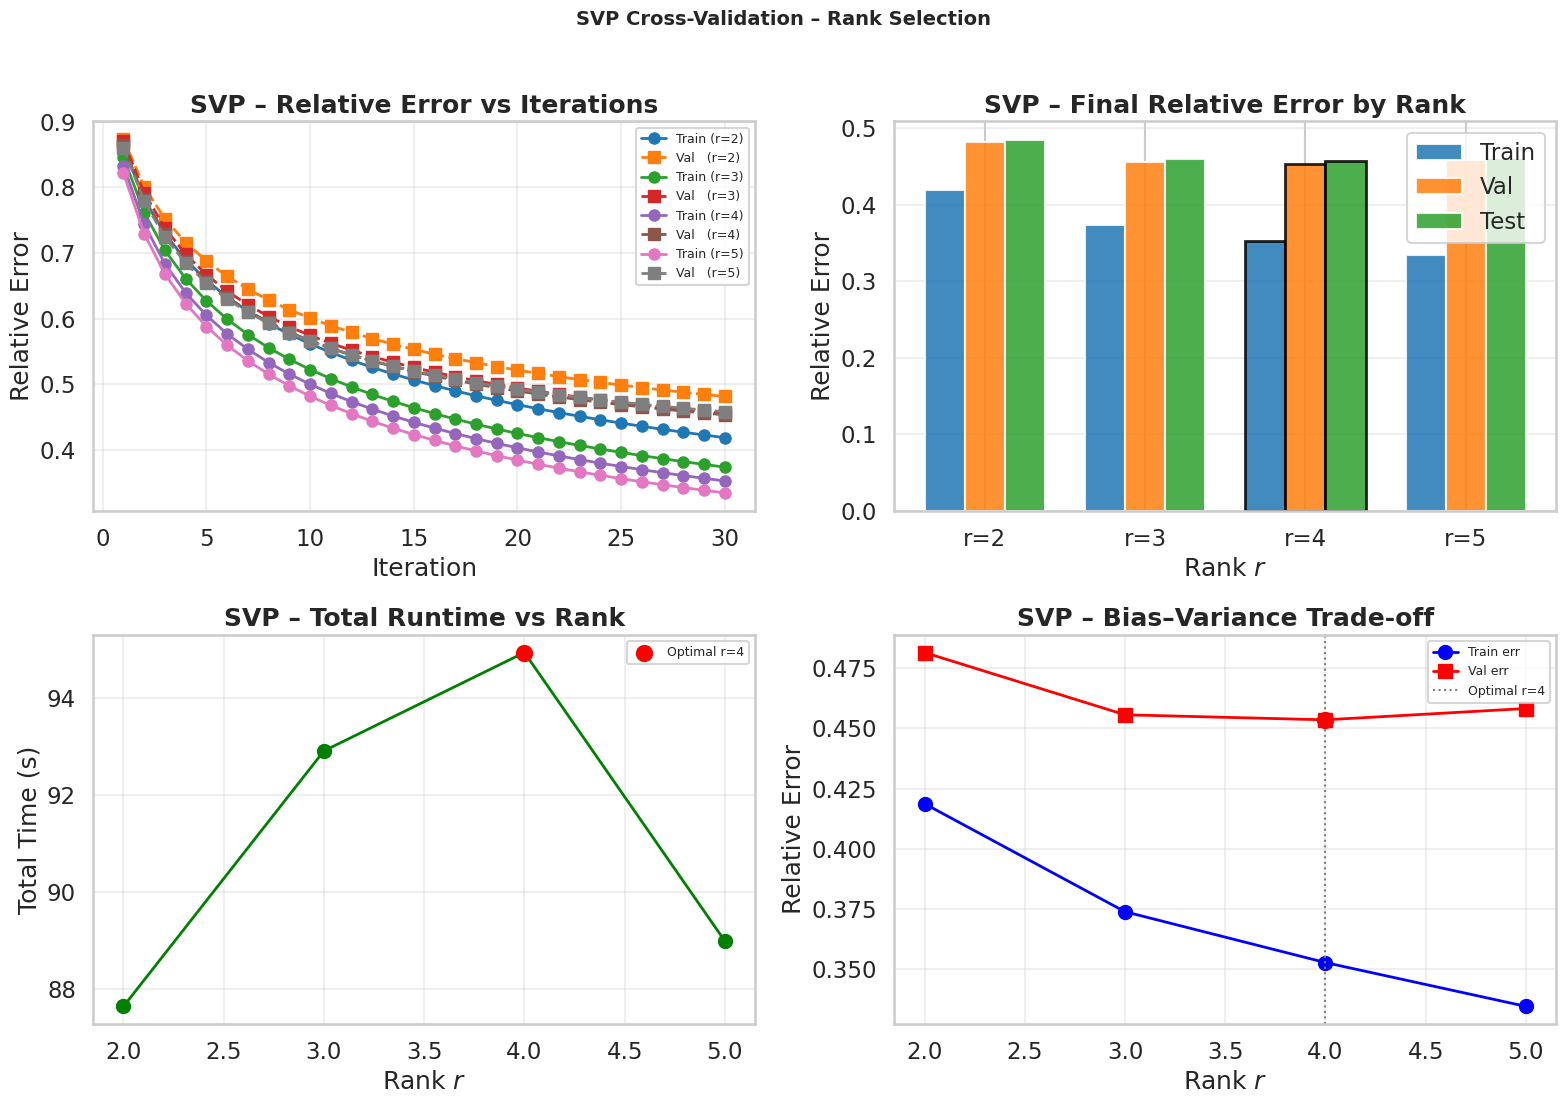

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
markersize = 8
linewidth  = 2

# ── Plot 1: relative error vs iterations ─────────────────────────────────────
for res in cv_results:
    h     = res['history']
    iters = range(1, len(h['err_train']) + 1)
    axes[0, 0].plot(iters, h['err_train'], 'o-',  label=f"Train (r={res['r']})",
                    lw=linewidth, ms=markersize)
    axes[0, 0].plot(iters, h['err_val'],   's--', label=f"Val   (r={res['r']})",
                    lw=linewidth, ms=markersize)

axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Relative Error')
axes[0, 0].set_title('SVP – Relative Error vs Iterations', fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: final relative error bar chart ───────────────────────────────────
ranks      = [res['r']         for res in cv_results]
err_trains = [res['err_train'] for res in cv_results]
err_vals   = [res['err_val']   for res in cv_results]
err_tests  = [res['err_test']  for res in cv_results]

x, w = np.arange(len(ranks)), 0.25
bars_tr  = axes[0, 1].bar(x - w, err_trains, w, label='Train', alpha=0.85)
bars_val = axes[0, 1].bar(x,     err_vals,   w, label='Val',   alpha=0.85)
bars_te  = axes[0, 1].bar(x + w, err_tests,  w, label='Test',  alpha=0.85)

# Highlight the best rank (minimum validation error)
best_idx = int(np.argmin(err_vals))
for bar_group, idx in [(bars_tr, best_idx), (bars_val, best_idx), (bars_te, best_idx)]:
    bar_group[idx].set_edgecolor('black')
    bar_group[idx].set_linewidth(2)

axes[0, 1].set_xlabel('Rank $r$')
axes[0, 1].set_ylabel('Relative Error')
axes[0, 1].set_title('SVP – Final Relative Error by Rank', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels([f"r={r}" for r in ranks])
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')

# ── Plot 3: computation time ──────────────────────────────────────────────────
times = [res['history']['time'][-1] for res in cv_results]
axes[1, 0].plot(ranks, times, 'go-', lw=linewidth, ms=markersize + 2)
# Highlight best rank
axes[1, 0].scatter([ranks[best_idx]], [times[best_idx]],
                   color='red', zorder=5, s=120, label=f'Optimal r={ranks[best_idx]}')
axes[1, 0].set_xlabel('Rank $r$')
axes[1, 0].set_ylabel('Total Time (s)')
axes[1, 0].set_title('SVP – Total Runtime vs Rank', fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# ── Plot 4: overfitting analysis ──────────────────────────────────────────────
axes[1, 1].plot(ranks, err_trains, 'bo-', label='Train err', lw=linewidth, ms=markersize + 2)
axes[1, 1].plot(ranks, err_vals,   'rs-', label='Val err',   lw=linewidth, ms=markersize + 2)
# Vertical line at optimal rank
axes[1, 1].axvline(ranks[best_idx], color='gray', linestyle=':', linewidth=1.5,
                   label=f'Optimal r={ranks[best_idx]}')
# Mark the optimal point on val curve
axes[1, 1].scatter([ranks[best_idx]], [err_vals[best_idx]],
                   color='red', zorder=5, s=120)
axes[1, 1].set_xlabel('Rank $r$')
axes[1, 1].set_ylabel('Relative Error')
axes[1, 1].set_title('SVP – Bias–Variance Trade-off', fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('SVP Cross-Validation – Rank Selection', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Cross-Validation Results for SVP Rank Selection

We performed cross-validation for the SVP algorithm using candidate ranks **r = 2, 3, 4, 5**,
each run for 30 iterations.  
Model selection is based primarily on **relative error** over the validation set, while the
**test set** is used only for final confirmation. We also report **RMSE** as a complementary
reconstruction metric.

---

### Performance Summary

| Rank $r$ | **Train err** | **Val err** | **Test err** | **RMSE train** | **RMSE val** | **RMSE test** |
|---------|--------------|------------|-------------|---------------|-------------|--------------|
| 2       | 0.4187       | 0.4814     | 0.4847      | 1.5306        | 1.7616      | 1.7649       |
| 3       | 0.3739       | 0.4556     | 0.4594      | 1.3667        | 1.6671      | 1.6726       |
| **4**   | **0.3528**   | **0.4535** ← best | **0.4568** | 1.2896 | **1.6594** | **1.6634** |
| 5       | 0.3346       | 0.4582     | 0.4616      | **1.2231**    | 1.6766      | 1.6809       |

---

### Key Observations

**Training error decreases monotonically with rank**, as expected: higher rank gives the
model more expressive power, reducing training error at every step.

**Validation error reaches a minimum at r = 4.**  
Performance improves from r=2 through r=4, but degrades at r=5:
- r=2 → r=3: large improvement (0.4814 → 0.4556)  
- r=3 → r=4: small but consistent improvement (0.4556 → 0.4535)  
- r=4 → r=5: slight degradation (0.4535 → 0.4582)

This is the classic signature of overfitting setting in beyond the optimal rank.

**Test error confirms the same pattern**, being minimised at r=4 (0.4568), consistent
with the validation selection.

**RMSE follows the same trend**: both validation and test RMSE are lowest at r=4,
while r=5 increases them despite a lower training RMSE.

---

### Bias–Variance Trade-off

| | |
|---|---|
| $r$ too small | high bias, underfitting, large train and val error |
| $r = 4$ | best balance, lowest validation error and RMSE |
| $r$ too large | lower train error but higher val error — overfitting |

---

### Note on iteration cap

Compared to previous experiments run with 50 iterations, these runs are capped at
**30 iterations**. SVP has not fully converged at this point (errors are still
decreasing at iter 30 for all ranks), so the absolute error values are higher than
those obtained with 50 iterations. However, all runs use the same cap, so the
**relative ranking across ranks remains valid** and the selection of $r=4$ is reliable.

---

### Final Selection

**Optimal rank: $r = 4$**

It achieves the lowest validation error (0.4535) and validation RMSE (1.6594), with
consistent confirmation on the test set, while r=5 already shows the first signs of
overfitting.

# Part 4: Algorithm Implementation – SVT (Singular Value Thresholding)

## Overview
The Singular Value Thresholding (SVT) algorithm replaces the hard rank constraint of SVP with **soft thresholding** on singular values.  
It is analogous to **LASSO / convex relaxation** in sparse regression: instead of enforcing a discrete rank constraint, it penalises the nuclear norm $\|X\|_*$, which is the convex relaxation of the rank function.

Unlike SVP, the rank is **not fixed in advance** but emerges automatically depending on the threshold parameter.

---

## Pseudocode

**Algorithm 2 – Singular Value Thresholding (SVT)**

**Input:**  
- Observed set $S$  
- Observed matrix $Y^S$  
- Threshold parameter $\lambda$  
- Step size $\eta$

**Initialize:**  
$X_0 = 0$

**While** stopping criterion is not met **do**

$X_{t+\frac{1}{2}} \leftarrow X_t + \eta \left( Y^S - X_t^S \right)$

$[U, \Sigma, V] \leftarrow \mathrm{SVD}\!\left(X_{t+\frac{1}{2}}\right)$

$X_{t+1} \leftarrow U\, S_\lambda(\Sigma)\, V^\top$

$t \leftarrow t + 1$

**End while**

**Return:** $X_t$

where:

- for singular values $\sigma_i \ge 0$, the **soft-thresholding** operator is
  $$
  S_\lambda(\sigma_i) = \max(\sigma_i - \lambda,\, 0);
  $$
- $S_\lambda(\Sigma)$ applies this rule to all singular values;
- $\eta > 0$ is the learning rate (step size); $\eta = 1$ gives the baseline version.

---

## Error Measure and Stopping Criterion

We use the **same error metric and stopping criterion as in SVP**:

The algorithm stops when either:

- the reconstruction error falls below a tolerance $\varepsilon$, or  
- the error no longer improves between iterations, or  
- a maximum number of iterations is reached (safety cap).

---

## Mathematical Connection

SVT can be interpreted as a proximal-gradient method for the convex problem:

$$
\min_X \; \frac{1}{2}\lVert X^S - Y^S \rVert_F^2 + \lambda\,\lVert X \rVert_*,
$$

where

$$
\lVert X \rVert_* = \sum_i \sigma_i
$$

is the **nuclear norm** (sum of singular values).

This is the convex relaxation of rank minimisation, directly analogous to how the $\ell_1$ norm relaxes sparsity in LASSO.

---

## Key Features

- Soft thresholding on singular values (continuous shrinkage, not hard truncation)
- Convex optimisation formulation
- **Automatic rank selection** via the parameter $\lambda$
- Threshold $\lambda$ acts as a regularisation hyperparameter and will be tuned via validation
- Requires an SVD at each iteration → higher computational cost than SVP
- Step size $\eta$ can be tuned to improve convergence speed

---

# Implementation

## Step 1 – Data Preparation (Reusing the Fixed Split)

We reuse the same fixed train/validation/test split defined earlier, to ensure a fair comparison with SVP.


## Step 2 – Soft-Thresholding Operator $S_\lambda$

In [ ]:
def soft_threshold(s, lam):
    """
    Soft-thresholding for singular values (s >= 0):

        S_λ(s) = max(s - λ, 0)

    Used to threshold singular values in SVT.
    """
    return np.maximum(s - lam, 0.0)

## Step 3 – SVT Algorithm

In [ ]:
import numpy as np
import time

# -----------------------------
# Soft-thresholding function
# -----------------------------
def soft_threshold(s, lam):
    """
    Soft-thresholding for singular values (s >= 0):

        S_λ(s) = max(s - λ, 0)

    Used to threshold singular values in SVT.
    """
    return np.maximum(s - lam, 0.0)

# -----------------------------
# SVT Algorithm
# -----------------------------
def SVT_algorithm(Y_S_train, Y_S_val, lam, eta=1.0,
                  epsilon=1e-2, max_iter=100, verbose=True):
    """
    Singular Value Thresholding – Algorithm 2 (Cai, Candès, Shen, 2008).

    Stopping criterion:
      • err(X_t, Y_S_val) < epsilon             [convergence]
      • err(X_{t+1}, Y_S_val) >= err(X_t, Y_S_val)  [no improvement]

    Parameters
    ----------
    Y_S_train : csr_matrix  – observed training ratings
    Y_S_val   : csr_matrix  – observed validation ratings
    lam       : float       – soft thresholding parameter λ
    eta       : float       – learning rate η (default 1.0)
    epsilon   : float       – convergence threshold (default 1e-2)
    max_iter  : int         – safety cap on iterations
    verbose   : bool        – print progress

    Returns
    -------
    X       : ndarray  – final predicted matrix
    history : dict       – err_train, err_val, eff_rank, total_time
    """
    n, m = Y_S_train.shape
    rows_tr, cols_tr = Y_S_train.nonzero()

    # -----------------------------
    # Initialise
    # -----------------------------
    X = np.zeros((n, m))
    history = {'err_train': [], 'err_val': [], 'eff_rank': [], 'total_time': []}
    t0 = time.time()

    if verbose:
        print(f"SVT  λ={lam}  η={eta}  |  matrix {n}×{m}")
        print("-" * 60)

    for t in range(max_iter):

        # -----------------------------
        # Gradient step on observed entries (optimized)
        # -----------------------------
        X_half = X.copy()
        X_half[rows_tr, cols_tr] += eta * (Y_S_train[rows_tr, cols_tr].A1 - X[rows_tr, cols_tr])

        # -----------------------------
        # Full SVD
        # -----------------------------
        U, s, Vt = np.linalg.svd(X_half, full_matrices=False)

        # -----------------------------
        # Soft-threshold singular values
        # -----------------------------
        s_thresh = soft_threshold(s, lam)
        X_new = U @ np.diag(s_thresh) @ Vt

        # -----------------------------
        # Track effective rank and errors
        # -----------------------------
        eff_rank  = int(np.sum(s_thresh > 1e-10))
        err_train = relative_error(X_new, Y_S_train)
        err_val   = relative_error(X_new, Y_S_val)

        history['err_train'].append(err_train)
        history['err_val'].append(err_val)
        history['eff_rank'].append(eff_rank)
        history['total_time'].append(time.time() - t0)

        if verbose and (t < 5 or t % 5 == 4):
            print(f"  iter {t+1:3d}  err_train={err_train:.5f}  "
                  f"err_val={err_val:.5f}  "
                  f"eff_rank={eff_rank}  t={history['total_time'][-1]:.1f}s")

        # -----------------------------
        # Update
        # -----------------------------
        X = X_new

        # -----------------------------
        # Early stopping based on validation error
        # -----------------------------
        if err_val < epsilon:
            if verbose:
                print(f"\n  → Converged: val_err={err_val:.5f} < ε={epsilon}")
            break

        if len(history['err_val']) > 1 and err_val >= history['err_val'][-2]:
            if verbose:
                print(f"\n  → Stopped: no improvement on validation at iter {t+1}")
            break

    if verbose:
        print("-" * 60)
        print(f"  Finished: {len(history['err_train'])} iters  "
              f"total time={history['total_time'][-1]:.1f}s  "
              f"final eff_rank={history['eff_rank'][-1]}")

    return X, history


## Step 4 – Build Sparse Matrices (Reused)
We reuse the same user/movie ID mappings and the same sparse matrices $Y^S_{\text{train}}$, $Y^S_{\text{val}}$, and $Y^S_{\text{test}}$ constructed earlier (SVP section), to keep all algorithm comparisons fully consistent.


## Step 5 – Cross-Validation over λ (Refined Grid)

Building on the initial broad sweep over $\lambda \in [10, 50]$, we refine the search
to a **narrower logarithmic grid** between $10^{1.3} \approx 20$ and
$10^{1.7} \approx 50$ (6 candidate values). The lower bound is motivated by the
results of the first experiment:

- **Small $\lambda$ (e.g. $\lambda = 10$):** the soft-thresholding penalty is too weak
  to suppress low-energy singular components, resulting in a very high effective rank
  ($\geq 163$). The model retains noise-driven directions, leading to severe
  overfitting — training error is low (0.207) but validation error remains above 0.60.
- **Intermediate $\lambda \approx 25$:** the penalty is strong enough to drive the
  effective rank down to a moderate level ($\approx 35$), yielding the best
  bias–variance tradeoff observed in the first sweep.
- **Large $\lambda$ (e.g. $\lambda = 50$):** too many singular values are zeroed out
  (effective rank $\leq 6$), the model underfits and validation error rises again.

We therefore restrict the refined grid to $\lambda \in [20, 50]$, excluding the
overfitting regime entirely and focusing the search around the previously identified
optimum. For each $\lambda$, we run SVT on the training set with fixed step size
$\eta = 1.0$ and a cap of 30 iterations, then evaluate on the validation set.

Model selection is based on the **validation relative error**:
$$
\mathrm{err}(X, Y) = \frac{\|X^S - Y^S\|_F}{\|Y^S\|_F},
$$
while RMSE is reported as a supplementary interpretability metric. The test set is used
only for final confirmation of the chosen $\lambda$, and never for tuning decisions.

For each candidate $\lambda$ we record:
- relative error on train, validation, and test sets (primary metric),
- RMSE on all three splits,
- **effective rank** (number of singular values surviving after thresholding),
- total wall-clock time.

At the end of the loop, the optimal $\lambda$ is selected as the one minimising the
validation error.

In [ ]:
import numpy as np

# -----------------------------
# Step 5 – Cross-Validation over λ (optimized)
# -----------------------------
# Generate a reasonable grid of λ values (logarithmic scale)
lambdas_to_test = np.logspace(1.3, 1.7, num=6)  # ~6 values between 10^1=10 and 10^1.7≈50
results_svt = []

for lam in lambdas_to_test:
    print(f"\n{'='*60}")
    print(f"SVT  –  λ = {lam:.2f}  (η = 1.0)")
    print(f"{'='*60}")

    # Run SVT
    X_final, history = SVT_algorithm(
        Y_S_train, Y_S_val,
        lam=lam,
        eta=1.0,
        epsilon=1e-2,
        max_iter=30,   # max iterations
        verbose=True
    )

    # Compute metrics
    err_tr  = relative_error(X_final, Y_S_train)
    err_val = relative_error(X_final, Y_S_val)
    err_te  = relative_error(X_final, Y_S_test)

    rmse_tr  = rmse(X_final, Y_S_train)
    rmse_val = rmse(X_final, Y_S_val)
    rmse_te  = rmse(X_final, Y_S_test)

    # Store results
    results_svt.append(dict(
        lam=lam,
        err_tr=err_tr, err_val=err_val, err_te=err_te,
        rmse_tr=rmse_tr, rmse_val=rmse_val, rmse_te=rmse_te,
        final_rank=history['eff_rank'][-1],
        total_time=history['total_time'][-1],
        history=history
    ))

# -----------------------------
# Select optimal λ based on minimum validation error
# -----------------------------
best_svt = min(results_svt, key=lambda x: x['err_val'])

print(f"\n{'='*60}")
print(f"Optimal λ found: {best_svt['lam']:.4f}")
print(f"Validation error: {best_svt['err_val']:.4f}")
print(f"Corresponding test error: {best_svt['err_te']:.4f}")
print(f"Effective rank: {best_svt['final_rank']}")
print(f"{'='*60}")



SVT  –  λ = 19.95  (η = 1.0)
SVT  λ=19.952623149688797  η=1.0  |  matrix 610×9724
------------------------------------------------------------
  iter   1  err_train=0.44005  err_val=0.94245  eff_rank=319  t=4.5s
  iter   2  err_train=0.42000  err_val=0.89527  eff_rank=267  t=11.3s
  iter   3  err_train=0.40777  err_val=0.85540  eff_rank=236  t=15.9s
  iter   4  err_train=0.39920  err_val=0.82119  eff_rank=211  t=21.7s
  iter   5  err_train=0.39289  err_val=0.79145  eff_rank=193  t=26.4s
  iter  10  err_train=0.37597  err_val=0.68660  eff_rank=137  t=52.9s
  iter  15  err_train=0.36788  err_val=0.62360  eff_rank=107  t=79.6s
  iter  20  err_train=0.36204  err_val=0.58224  eff_rank=86  t=106.5s
  iter  25  err_train=0.35757  err_val=0.55322  eff_rank=74  t=132.7s
  iter  30  err_train=0.35387  err_val=0.53174  eff_rank=63  t=160.9s
------------------------------------------------------------
  Finished: 30 iters  total time=160.9s  final eff_rank=63

SVT  –  λ = 23.99  (η = 1.0)
SVT  λ=

## Step 6 – Visualisation

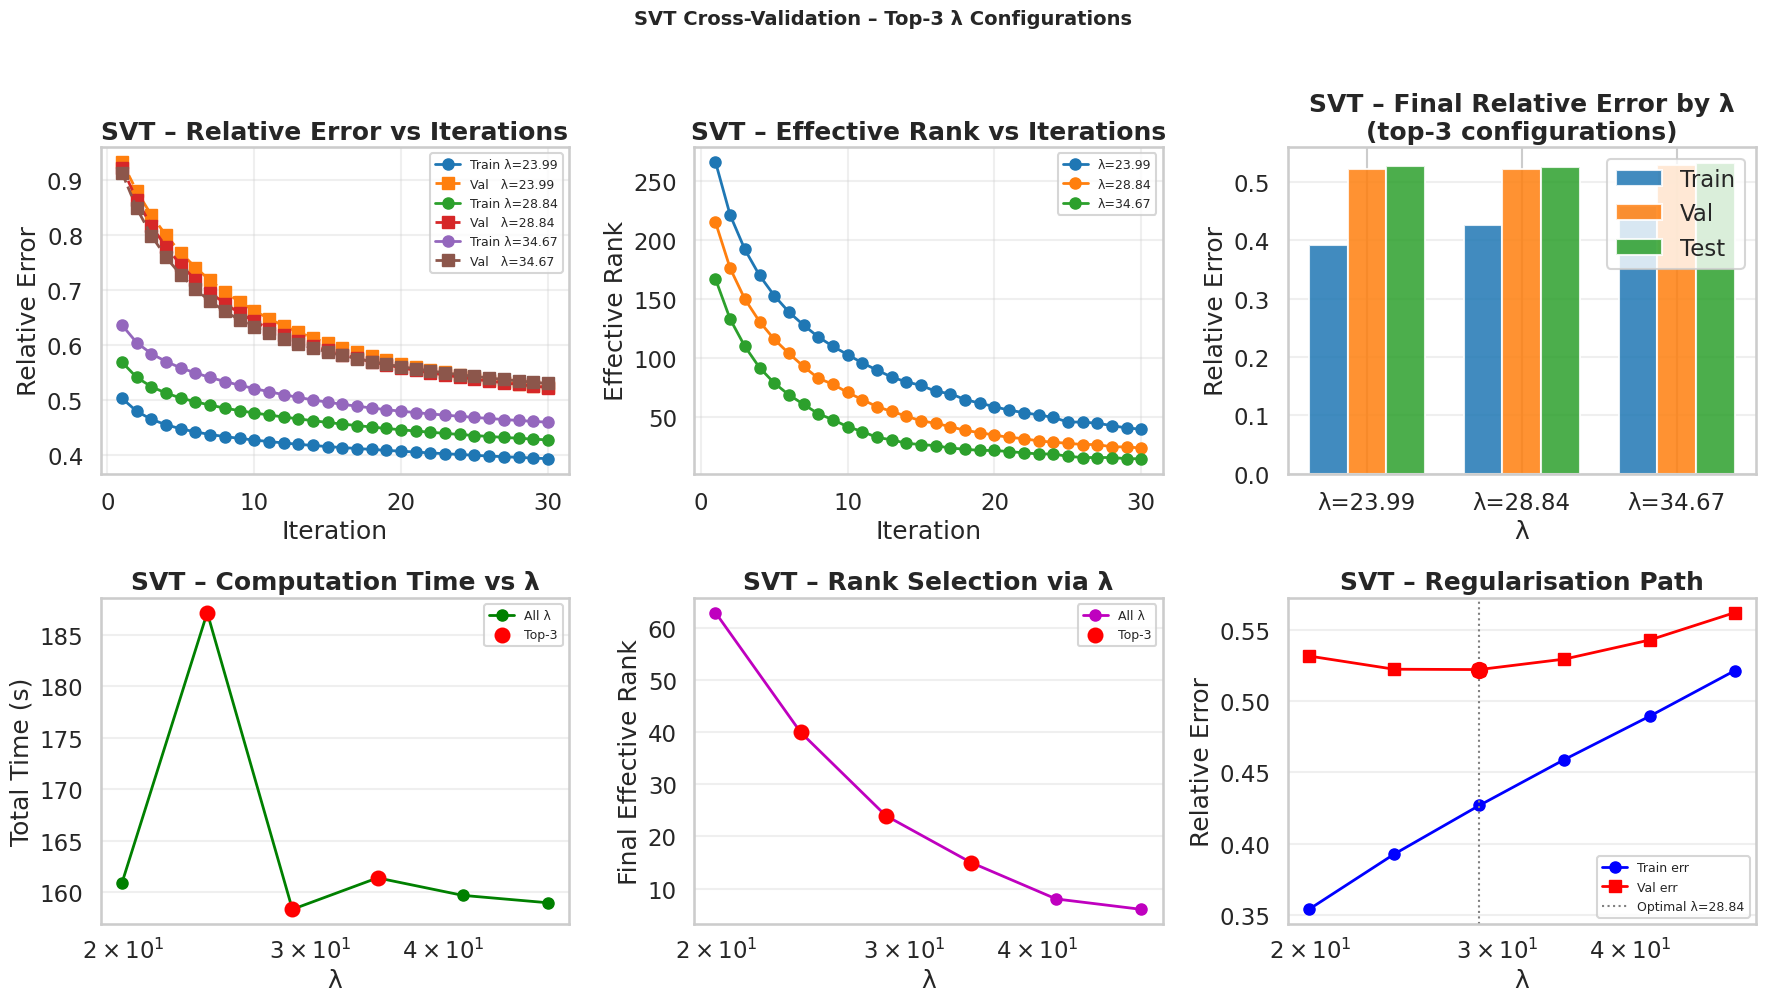

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
sns.set_context("talk")

# -----------------------------
# Select top 3 lambda values by validation error
# -----------------------------
results_svt_sorted = sorted(results_svt, key=lambda x: x['err_val'])
results_svt_top3   = sorted(results_svt_sorted[:3], key=lambda x: x['lam'])
lams = [res['lam'] for res in results_svt_top3]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
markersize = 8
linewidth  = 2

# ── Plot 1: Relative error vs iterations ───────────────────────────────
for res in results_svt_top3:
    h     = res['history']
    iters = range(1, len(h['err_train']) + 1)
    axes[0, 0].plot(iters, h['err_train'], 'o-',  label=f"Train λ={res['lam']:.2f}",
                    lw=linewidth, ms=markersize)
    axes[0, 0].plot(iters, h['err_val'],   's--', label=f"Val   λ={res['lam']:.2f}",
                    lw=linewidth, ms=markersize)

axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Relative Error')
axes[0, 0].set_title('SVT – Relative Error vs Iterations', fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: Effective rank evolution ───────────────────────────────────
for res in results_svt_top3:
    h     = res['history']
    iters = range(1, len(h['eff_rank']) + 1)
    axes[0, 1].plot(iters, h['eff_rank'], 'o-', label=f"λ={res['lam']:.2f}",
                    lw=linewidth, ms=markersize)

axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Effective Rank')
axes[0, 1].set_title('SVT – Effective Rank vs Iterations', fontweight='bold')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# ── Plot 3: Final relative error bar chart ─────────────────────────────
err_trs   = [res['err_tr']  for res in results_svt_top3]
err_vals  = [res['err_val'] for res in results_svt_top3]
err_tests = [res['err_te']  for res in results_svt_top3]

x, w = np.arange(len(lams)), 0.25
axes[0, 2].bar(x - w, err_trs,   w, label='Train', alpha=0.85)
axes[0, 2].bar(x,     err_vals,  w, label='Val',   alpha=0.85)
axes[0, 2].bar(x + w, err_tests, w, label='Test',  alpha=0.85)
axes[0, 2].set_xlabel('λ')
axes[0, 2].set_ylabel('Relative Error')
axes[0, 2].set_title('SVT – Final Relative Error by λ\n(top-3 configurations)',
                      fontweight='bold')
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f"λ={lam:.2f}" for lam in lams])
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3, axis='y')

# ── Plot 4: Computation time vs lambda (ALL results, not just top-3) ───
# Showing all λ values gives a more complete picture of runtime behaviour
all_lams  = [res['lam']        for res in results_svt]
all_times = [res['total_time'] for res in results_svt]
all_lams_sorted, all_times_sorted = zip(*sorted(zip(all_lams, all_times)))

axes[1, 0].plot(all_lams_sorted, all_times_sorted, 'go-', lw=linewidth, ms=markersize,
                label='All λ')
# Highlight the top-3
top3_times = [res['total_time'] for res in results_svt_top3]
axes[1, 0].scatter(lams, top3_times, color='red', zorder=5, s=100, label='Top-3')
axes[1, 0].set_xlabel('λ')
axes[1, 0].set_ylabel('Total Time (s)')
axes[1, 0].set_title('SVT – Computation Time vs λ', fontweight='bold')
axes[1, 0].set_xscale('log')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# ── Plot 5: Final effective rank vs lambda (ALL results) ───────────────
all_ranks = [res['final_rank'] for res in results_svt]
all_lams_s2, all_ranks_s = zip(*sorted(zip(all_lams, all_ranks)))

axes[1, 1].plot(all_lams_s2, all_ranks_s, 'mo-', lw=linewidth, ms=markersize,
                label='All λ')
top3_ranks = [res['final_rank'] for res in results_svt_top3]
axes[1, 1].scatter(lams, top3_ranks, color='red', zorder=5, s=100, label='Top-3')
axes[1, 1].set_xlabel('λ')
axes[1, 1].set_ylabel('Final Effective Rank')
axes[1, 1].set_title('SVT – Rank Selection via λ', fontweight='bold')
axes[1, 1].set_xscale('log')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

# ── Plot 6: Regularisation path (ALL results) ──────────────────────────
all_err_trs  = [res['err_tr']  for res in results_svt]
all_err_vals = [res['err_val'] for res in results_svt]
sorted_data  = sorted(zip(all_lams, all_err_trs, all_err_vals))
lams_s, etrs_s, evals_s = zip(*sorted_data)

axes[1, 2].plot(lams_s, etrs_s,  'bo-', label='Train err', lw=linewidth, ms=markersize)
axes[1, 2].plot(lams_s, evals_s, 'rs-', label='Val err',   lw=linewidth, ms=markersize)
# Mark optimal λ
best_lam = min(results_svt, key=lambda x: x['err_val'])['lam']
best_val = min(results_svt, key=lambda x: x['err_val'])['err_val']
axes[1, 2].axvline(best_lam, color='gray', linestyle=':', linewidth=1.5,
                   label=f'Optimal λ={best_lam:.2f}')
axes[1, 2].scatter([best_lam], [best_val], color='red', zorder=5, s=120)
axes[1, 2].set_xlabel('λ')
axes[1, 2].set_ylabel('Relative Error')
axes[1, 2].set_title('SVT – Regularisation Path', fontweight='bold')
axes[1, 2].set_xscale('log')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(alpha=0.3)

plt.suptitle('SVT Cross-Validation – Top-3 λ Configurations', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 7 – Results Summary

---

## Key Observations

### 1. λ controls regularisation strength and effective rank automatically

- **$\lambda = 19.95$ (weak regularisation):**  
  High effective rank ($63$) and lower training error ($\mathrm{err}_{\text{train}} = 0.354$),
  but poor validation performance ($\mathrm{err}_{\text{val}} = 0.532$).  
  The model retains too many singular components, fitting residual noise.

- **$\lambda = 28.84$ (optimal regularisation):**  
  Moderate effective rank ($24$) and training error ($\mathrm{err}_{\text{train}} = 0.427$),
  with **best** validation and test performance in the explored grid
  ($\mathrm{err}_{\text{val}} = 0.522$, $\mathrm{err}_{\text{test}} = 0.526$).

- **$\lambda = 50.12$ (strong regularisation):**  
  Very low effective rank ($6$) and high training error ($\mathrm{err}_{\text{train}} = 0.521$),
  with degraded validation performance ($\mathrm{err}_{\text{val}} = 0.562$).  
  The model underfits: too many singular values are zeroed out.

This confirms the expected **convex regularisation path**: increasing $\lambda$ reduces
model complexity while improving generalisation — up to a point.

---

### 2. Validation error follows a U-shaped curve over λ

| $\lambda$ | $\mathrm{err}_{\text{train}}$ | $\mathrm{err}_{\text{val}}$ | eff. rank | Time (s) |
|----------:|------------------------------:|----------------------------:|----------:|---------:|
| 19.95     | 0.3539                        | 0.5317                      | 63        | 160.9    |
| 23.99     | 0.3926                        | 0.5225                      | 40        | 187.2    |
| **28.84** | 0.4268                        | **0.5222** ← best           | **24**    | 158.3    |
| 34.67     | 0.4591                        | 0.5296                      | 15        | 161.4    |
| 41.69     | 0.4894                        | 0.5430                      | 8         | 159.7    |
| 50.12     | 0.5215                        | 0.5622                      | 6         | 159.0    |

- small $\lambda$ → overfitting, high rank, low training error, poor generalisation;
- $\lambda \approx 28.84$ → optimal tradeoff, lowest validation error;
- large $\lambda$ → underfitting, rank too low, validation error increases again.

Note that the U-shape is shallow around the optimum: $\lambda = 23.99$ and
$\lambda = 28.84$ yield nearly identical validation errors ($0.5225$ vs $0.5222$),
suggesting the model is not highly sensitive to the exact value of $\lambda$ in
this range.

---

### 3. Effective rank decreases progressively over iterations
For all $\lambda$, the effective rank drops during training due to cumulative
soft-thresholding:

- $\lambda = 28.84$: rank $215 \to 24$ over 30 iterations  
- $\lambda = 41.69$: rank $119 \to 8$ over 30 iterations  

This demonstrates SVT's ability to **adaptively select model complexity** at runtime.

---

### 4. All runs terminate at the iteration cap
None of the runs reach the convergence threshold $\mathrm{err}_{\text{train}} < 10^{-2}$,
nor does the "no improvement" criterion trigger. All runs terminate at the
**maximum iteration cap of 30**, with errors still slowly decreasing at the final
iteration — SVT has not fully converged on this dataset within the allowed budget.

---

### 5. Computation time
All runs take approximately **158–187 seconds**, with no clear dependence on $\lambda$.
Runtime is dominated by the **full SVD at every iteration**, whose cost is determined
by the matrix dimensions ($610 \times 9724$) rather than the effective rank.

---

## Connection to Preliminary Questions

- **Question (i):** SVT is the matrix-completion analogue of **LASSO / convex
  relaxation**: soft-thresholding on singular values minimises the nuclear norm
  $\|X\|_*$, the convex surrogate of the rank, exactly as LASSO's $\ell_1$ penalty
  is the convex surrogate of $\ell_0$ sparsity.

- **Question (ii):** The $\lambda$ sweep directly illustrates the **bias–variance
  tradeoff**: small $\lambda$ overfits, large $\lambda$ underfits, intermediate
  $\lambda$ balances the two.

- **Question (iii):** Even at optimal $\lambda$, the effective rank ($24$) is well
  below the $\approx 256$ components needed to explain 90% of variance in $Y^S$,
  confirming that high-order singular components capture noise rather than
  predictive structure.

---

## Limitations

- **Full SVD per iteration** → main computational bottleneck.
- **λ-sensitive** → despite the shallow U-shape around the optimum, performance
  degrades outside the optimal range and requires grid search to locate.
- **Implicit rank control** → the effective rank is a byproduct of $\lambda$,
  not directly controllable as a model hyperparameter.

# Part 5: Algorithm Implementation – ADMiRA (Atomic Decomposition for Minimum Rank Approximation)

## Overview
ADMiRA adopts a **greedy dictionary-based approach** to matrix completion.  
Rather than projecting globally onto the set of rank-$r$ matrices (SVP) or penalising the nuclear norm (SVT), it constructs the solution iteratively as a linear combination of **rank-1 atoms**, expanding and pruning a dictionary at each iteration.

It is directly analogous to **Orthogonal Matching Pursuit (OMP)** in sparse regression.

---

## Pseudocode

**Algorithm 3 – ADMiRA**

**Input:**  
- Observed set $S$  
- Observed matrix $Y^S$  
- Target rank $r$

**Initialize:**  
$X_0 = 0$, \quad $\Psi_0 = \emptyset$

**While** stopping criterion is not met **do**

$[U, \_, V] \leftarrow \mathrm{SVD}_{2r}\!\left(Y^S - X_t^S\right)$

$\Psi_{t+\frac{1}{2}} \leftarrow \Psi_t \cup \{ u_j v_j^\top : j \le 2r \}$

$X_{t+\frac{1}{2}} \leftarrow \arg\min \left\{ \lVert Y^S - X^S \rVert_F^2 : X \in \mathrm{span}(\Psi_{t+\frac{1}{2}}) \right\}$

$(U', \Sigma, V') \leftarrow \mathrm{SVD}_r\!\left(X_{t+\frac{1}{2}}\right)$

$\Psi_{t+1} \leftarrow \{ u'_j (v'_j)^\top : j \le r \}$

$X_{t+1} \leftarrow U' \Sigma (V')^\top$

$t \leftarrow t + 1$

**End while**

**Return:** $X_t$

---

## Key Idea: Atom Dictionary

The goal is to express the estimate $X_t$ as a linear combination of rank-1 atoms:
$$
X_t = \sum_{M \in \Psi_t} a_M \, M,
$$
where $\Psi_t$ is the current dictionary of rank-1 matrices and $a_M$ are scalar coefficients.

By construction,
$$
\mathrm{rank}(X_t) \le |\Psi_t|.
$$

At each iteration:
- **Atom selection (Steps 3–4):** the top $2r$ rank-1 components of the residual $Y^S - X_t^S$ are identified and added to the dictionary;
- **Coefficient update (Step 5):** all coefficients $a_M$ are re-optimised via least-squares regression on the observed entries;
- **Pruning (Steps 6–7):** the dictionary is reduced back to $r$ atoms by computing a rank-$r$ SVD of $X_{t+\frac{1}{2}}$;
- **Reconstruction (Step 8):** the rank-$r$ estimate is rebuilt from the pruned atoms.

---

## Error Measure and Stopping Criterion
The error measure and stopping criterion are **identical to SVP and SVT**, following the assignment specification.

The primary metric is the relative error on the observed entries:
$$
\mathrm{err}(X, Y) = \frac{\lVert X^S - Y^S \rVert_F}{\lVert Y^S \rVert_F}.
$$

The algorithm stops when either:
- $\mathrm{err}(X_t, Y) < \varepsilon$ (convergence), or
- $\mathrm{err}(X_{t+1}, Y) \ge \mathrm{err}(X_t, Y)$ (no further improvement).

The **RMSE** on observed entries is reported **only as a supplementary metric**.

---

## Key Features
- Greedy atom selection analogous to Matching Pursuit
- Least-squares optimisation of coefficients at each iteration
- Alternates between dictionary expansion (residual-driven) and pruning (via SVD)
- Requires specifying the target rank $r$ in advance, similarly to SVP

---

# Implementation

## Step 1 – Data Preparation

We reuse the same data + fixed train/val/test split defined earlier in the notebook.


## Step 2 – Helper Functions

In [ ]:
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix
from scipy.sparse.linalg import svds
from scipy.linalg import lstsq

def svd_2r_atoms(M, r):
    """
    SVD_{2r}: compute top-2r singular triplets of M and return rank-1 atoms
    in FACTORISED form as (u_j, v_j), representing u_j v_j^T.

    Implements line 3 of Algorithm 3.
    IMPORTANT: uses truncated SVD (svds), not full SVD.
    """
    k = min(2 * r, min(M.shape) - 1)

    U, s, Vt = svds(M, k=k)

    # svds returns ascending singular values -> reverse to descending
    U  = U[:, ::-1]
    s  = s[::-1]
    Vt = Vt[::-1, :]

    # Return atoms as factor pairs (u, v); scaling by singular values is optional here.
    # The LS step will fit coefficients anyway, so we keep pure directions.
    return [(U[:, j], Vt[j, :]) for j in range(k)]


def solve_ls(atoms, Y_S):
    """
    Step 5 (Algorithm 3):
        X_{t+1/2} = argmin ||Y^S - X^S||_F^2  s.t. X in span(Psi)

    We solve least squares over observed entries only:
        min ||A c - b||^2
    where each column j corresponds to atom_j evaluated on observed positions:
        (u_j v_j^T)_{(row_i, col_i)} = u_j[row_i] * v_j[col_i]
    """
    Y_coo = Y_S.tocoo()
    rows = Y_coo.row
    cols = Y_coo.col
    b    = Y_coo.data.astype(float)

    n_obs   = len(b)
    n_atoms = len(atoms)

    A = np.zeros((n_obs, n_atoms), dtype=float)

    for j, (u, v) in enumerate(atoms):
        A[:, j] = u[rows] * v[cols]

    coeffs, _, _, _ = lstsq(A, b, lapack_driver='gelsy')
    return coeffs


## Step 3 – ADMiRA Algorithm

In [ ]:
def ADMiRA_algorithm(Y_S_train, Y_S_val, r, epsilon=1e-2, max_iter=50, verbose=True):
    """
    ADMiRA – Algorithm 3 (Lee & Bresler, 2009).

    Stopping criterion (assignment specification):
      • err(X_t, Y) < epsilon           [convergence]
      • err(X_{t+1}, Y) > err(X_t, Y)  [no improvement]

    Returns
    -------
    X       : ndarray  – final predicted matrix
    history : dict     – err_train, err_val, psi_size, time per iteration
    """
    n, m = Y_S_train.shape

    # Work once in COO for observed positions
    Ytr = Y_S_train.tocoo()
    rows_tr, cols_tr, y_tr = Ytr.row, Ytr.col, Ytr.data

    # Line 1 – initialise
    X   = np.zeros((n, m))
    Psi = []   # dictionary of atoms as (u, v) pairs

    history = {'err_train': [], 'err_val': [], 'psi_size': [], 'time': []}
    t0 = time.time()

    if verbose:
        print(f"ADMiRA  r={r}  |  matrix {n}×{m}")
        print("-" * 60)

    for t in range(max_iter):

        # ── Line 3: SVD_{2r}(Y^S - X_t^S) on observed entries ─────────
        res_data = y_tr - X[rows_tr, cols_tr]
        residual = coo_matrix((res_data, (rows_tr, cols_tr)), shape=(n, m)).tocsr()

        new_atoms = svd_2r_atoms(residual, r)   # returns [(u_j, v_j)] for j<=2r

        # ── Line 4: expand dictionary ─────────────────────────────────
        Psi_half = Psi + new_atoms

        # ── Line 5: least squares in span(Psi_half) ───────────────────
        coeffs = solve_ls(Psi_half, Y_S_train)

        # Build X_{t+1/2} efficiently from atoms (u,v) and coeffs
        Umat = np.column_stack([u for (u, v) in Psi_half])   # (n, p)
        Vmat = np.column_stack([v for (u, v) in Psi_half])   # (m, p)
        X_half = (Umat * coeffs) @ Vmat.T                    # (n, m)

        # ── Lines 6–8: prune via SVD_r(X_half) and reconstruct ────────
        k = min(r, min(X_half.shape) - 1)
        U2, s2, Vt2 = svds(X_half, k=k)

        # svds returns ascending singular values → reverse to descending
        U2  = U2[:, ::-1]
        s2  = s2[::-1]
        Vt2 = Vt2[::-1, :]

        # Update dictionary Ψ_{t+1} (as (u,v) pairs) and X_{t+1}
        Psi = [(U2[:, j], Vt2[j, :]) for j in range(k)]
        X   = U2[:, :k] @ np.diag(s2[:k]) @ Vt2[:k, :]

        # Metrics
        err_train = relative_error(X, Y_S_train)
        err_val   = relative_error(X, Y_S_val)
        elapsed   = time.time() - t0

        history['err_train'].append(err_train)
        history['err_val'].append(err_val)
        history['psi_size'].append(len(Psi))
        history['time'].append(elapsed)

        if verbose and (t < 5 or t % 5 == 4):
            print(f"  iter {t+1:3d}  err_train={err_train:.5f}  "
                  f"err_val={err_val:.5f}  |Ψ|={len(Psi)}  t={elapsed:.1f}s")

        # Stopping criterion
        if err_train < epsilon:
            if verbose:
                print(f"\n  → Converged: err={err_train:.5f} < ε={epsilon}")
            break
        if len(history['err_train']) > 1 and err_train >= history['err_train'][-2]:
            if verbose:
                print(f"\n  → Stopped: no improvement at iter {t+1}")
            break

    if verbose:
        print("-" * 60)
        print(f"  Finished: {len(history['err_train'])} iters  "
              f"time={history['time'][-1]:.1f}s  |Ψ|={history['psi_size'][-1]}")

    return X, history


## Step 4 – Build Sparse Matrices
We reuse the same user/movie index mappings and build $Y^S_{\text{train}}$, $Y^S_{\text{val}}$, and $Y^S_{\text{test}}$ from the fixed 60/20/20 split, to keep all algorithms directly comparable.


## STEP 5 – ADMiRA – Cross-Validation for Rank Selection

In this section, we perform a **cross-validation procedure** to select the optimal rank \(r\) for the ADMiRA algorithm.  

Key points:

- **Rank selection:** ADMiRA requires specifying a target rank \(r\) in advance. Choosing \(r\) too small may underfit the data, while too large a rank increases computational cost and can overfit.
- **Validation-based choice:** We evaluate multiple candidate ranks on the **validation set** and select the one achieving the **lowest validation error**.
- **Runtime considerations:** To keep execution time reasonable, we restrict the search to a small set of ranks (`r_values = [3, 5, 8, 10, 12]`) and limit the maximum number of iterations (`max_iter = 30`).
- **Metrics recorded:** For each rank \(r\) we store:
  - Training, validation, and test **relative errors**  
  - Supplementary **RMSE**  
  - Final **dictionary size** \(|\Psi|\)  
  - Iteration-wise **history** for error and dictionary growth
- **Stopping criteria:** identical to the ADMiRA algorithm – either convergence (`err_train < epsilon`) or no further improvement.

The code iterates over all candidate ranks, runs ADMiRA, records metrics, and prints a summary of the **best-performing rank** with its validation and test errors and final dictionary size.



In [ ]:
# -----------------------------
# Cross-validation to select best rank r for ADMiRA
# -----------------------------
r_values = [3, 5, 8, 10, 12]  # reasonable range to keep runtime low
results_admira = []

print(f"\n{'='*60}")
print("ADMiRA – Cross-validation over ranks")
print(f"{'='*60}")

best_val = np.inf
best_r   = None

for r in r_values:
    print(f"\n{'-'*60}")
    print(f"Running ADMiRA with rank r = {r}")

    X_final, history = ADMiRA_algorithm(
        Y_S_train, Y_S_val,
        r=r,
        epsilon=1e-2,
        max_iter=30,
        verbose=True
    )

    # Primary metric: relative error
    err_tr  = relative_error(X_final, Y_S_train)
    err_val = relative_error(X_final, Y_S_val)
    err_te  = relative_error(X_final, Y_S_test)

    # Supplementary metric: RMSE
    rmse_tr  = rmse(X_final, Y_S_train)
    rmse_val = rmse(X_final, Y_S_val)
    rmse_te  = rmse(X_final, Y_S_test)

    print(f"\n  Relative error  –  train: {err_tr:.4f}  val: {err_val:.4f}  test: {err_te:.4f}")
    print(f"  RMSE (extra)    –  train: {rmse_tr:.4f}  val: {rmse_val:.4f}  test: {rmse_te:.4f}")

    results_admira.append(dict(
        r=r, iters=len(history['err_train']),
        err_tr=err_tr, err_val=err_val, err_te=err_te,
        rmse_tr=rmse_tr, rmse_val=rmse_val, rmse_te=rmse_te,
        psi_size=history['psi_size'][-1],
        time=history['time'][-1],
        history=history
    ))

    # Keep track of best rank according to validation error
    if err_val < best_val:
        best_val = err_val
        best_r   = r

print(f"\n{'='*60}")
print(f"Optimal r found: {best_r}")
print(f"Validation error: {best_val:.4f}")
best_te = next(res['err_te'] for res in results_admira if res['r'] == best_r)
best_psi = next(res['psi_size'] for res in results_admira if res['r'] == best_r)
print(f"Corresponding test error: {best_te:.4f}")
print(f"Final dictionary size: {best_psi}")
print(f"{'='*60}")



ADMiRA – Cross-validation over ranks

------------------------------------------------------------
Running ADMiRA with rank r = 3
ADMiRA  r=3  |  matrix 610×9724
------------------------------------------------------------
  iter   1  err_train=0.72573  err_val=0.75177  |Ψ|=3  t=1.8s
  iter   2  err_train=0.61909  err_val=0.66498  |Ψ|=3  t=3.6s
  iter   3  err_train=0.56247  err_val=0.61638  |Ψ|=3  t=5.4s
  iter   4  err_train=0.51947  err_val=0.57970  |Ψ|=3  t=7.1s
  iter   5  err_train=0.48691  err_val=0.54868  |Ψ|=3  t=8.9s
  iter  10  err_train=0.40349  err_val=0.47847  |Ψ|=3  t=19.4s
  iter  15  err_train=0.37786  err_val=0.46109  |Ψ|=3  t=29.4s
  iter  20  err_train=0.36651  err_val=0.45232  |Ψ|=3  t=39.3s
  iter  25  err_train=0.36012  err_val=0.44707  |Ψ|=3  t=48.4s
  iter  30  err_train=0.35672  err_val=0.44500  |Ψ|=3  t=58.1s
------------------------------------------------------------
  Finished: 30 iters  time=58.1s  |Ψ|=3

  Relative error  –  train: 0.3567  val: 0.4450  

## Step 6 – Visualisation


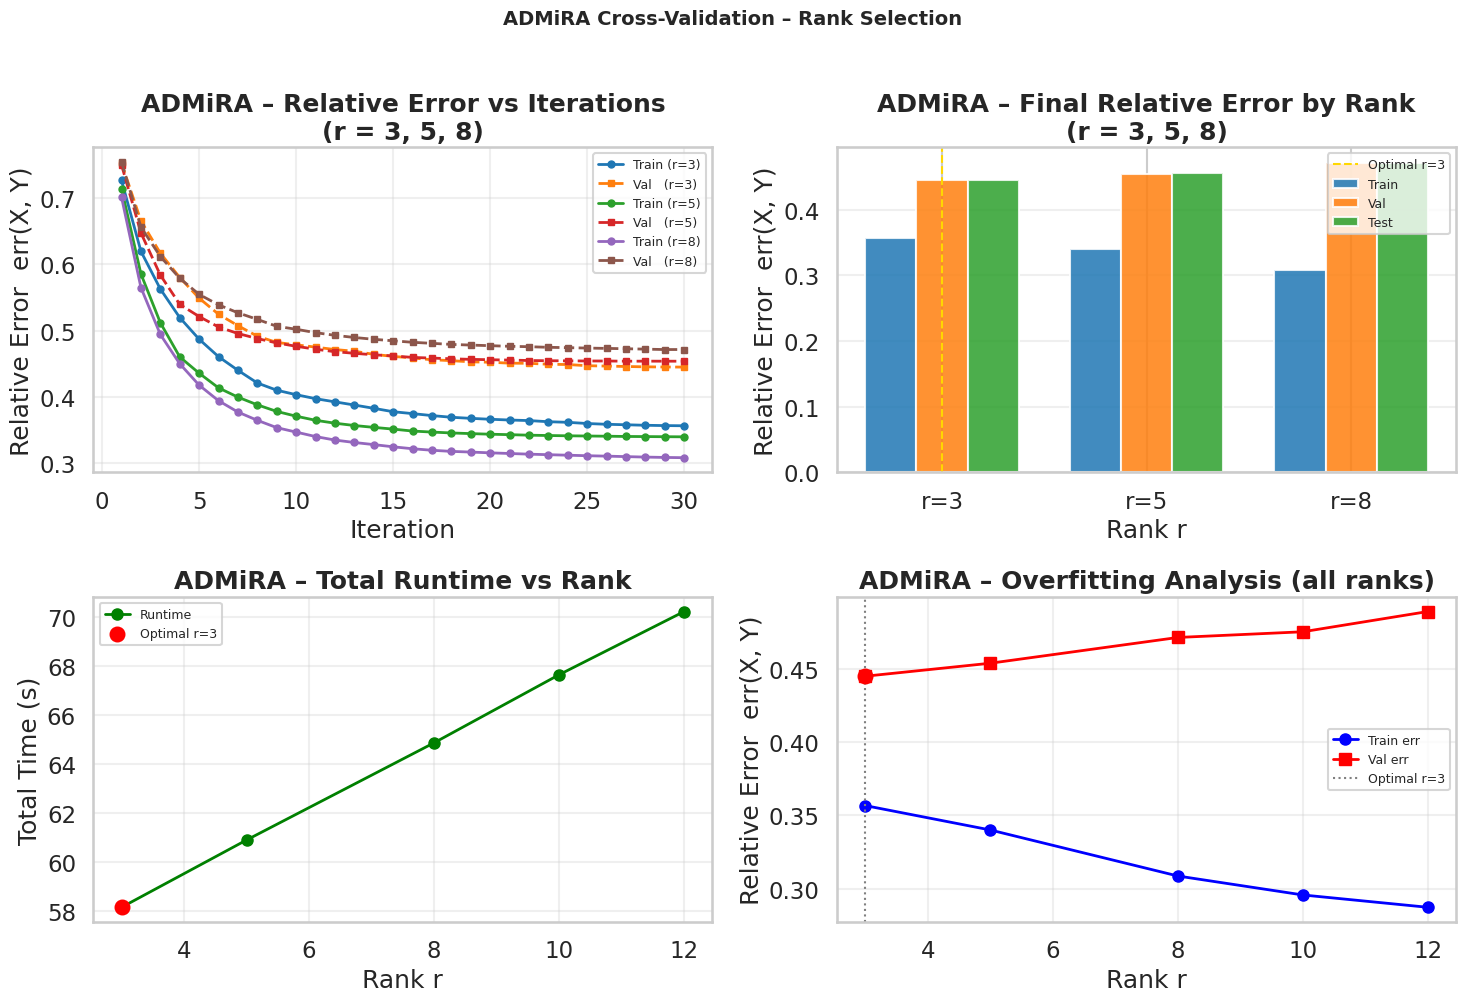

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Use only the most significant ranks for plots 1 & 2 ─────────────────────
# r=3 is optimal; r=5 and r=8 show the onset of overfitting
significant_ranks = [3, 5, 8]
cv_results_signif = [res for res in results_admira if res['r'] in significant_ranks]

# ── Plot 1: Relative error vs iterations (significant ranks) ─────────────
for res in cv_results_signif:
    h     = res['history']
    iters = range(1, len(h['err_train']) + 1)
    axes[0, 0].plot(iters, h['err_train'], 'o-',  label=f"Train (r={res['r']})", lw=2, ms=5)
    axes[0, 0].plot(iters, h['err_val'],   's--', label=f"Val   (r={res['r']})", lw=2, ms=5)

axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Relative Error  err(X, Y)')
axes[0, 0].set_title('ADMiRA – Relative Error vs Iterations\n(r = 3, 5, 8)',
                      fontweight='bold')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: Final relative error bar chart (significant ranks) ───────────
ranks_signif = [res['r']      for res in cv_results_signif]
err_trains_s = [res['err_tr'] for res in cv_results_signif]
err_vals_s   = [res['err_val'] for res in cv_results_signif]
err_tests_s  = [res['err_te'] for res in cv_results_signif]

x, w = np.arange(len(ranks_signif)), 0.25
axes[0, 1].bar(x - w, err_trains_s, w, label='Train', alpha=0.85)
axes[0, 1].bar(x,     err_vals_s,   w, label='Val',   alpha=0.85)
axes[0, 1].bar(x + w, err_tests_s,  w, label='Test',  alpha=0.85)
# Highlight the optimal rank
axes[0, 1].axvline(x=0, color='gold', linestyle='--', linewidth=1.5,
                   label='Optimal r=3')
axes[0, 1].set_xlabel('Rank r')
axes[0, 1].set_ylabel('Relative Error  err(X, Y)')
axes[0, 1].set_title('ADMiRA – Final Relative Error by Rank\n(r = 3, 5, 8)',
                      fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels([f"r={r}" for r in ranks_signif])
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3, axis='y')

# ── Plot 3: Computation time vs all ranks ─────────────────────────────────
ranks_all = [res['r']    for res in results_admira]
times_all = [res['time'] for res in results_admira]

axes[1, 0].plot(ranks_all, times_all, 'go-', lw=2, ms=8, label='Runtime')
# Highlight optimal rank
opt_time = next(res['time'] for res in results_admira if res['r'] == 3)
axes[1, 0].scatter([3], [opt_time], color='red', zorder=5, s=100,
                   label='Optimal r=3')
axes[1, 0].set_xlabel('Rank r')
axes[1, 0].set_ylabel('Total Time (s)')
axes[1, 0].set_title('ADMiRA – Total Runtime vs Rank', fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# ── Plot 4: Overfitting analysis vs all ranks ─────────────────────────────
err_trains_all = [res['err_tr']  for res in results_admira]
err_vals_all   = [res['err_val'] for res in results_admira]

axes[1, 1].plot(ranks_all, err_trains_all, 'bo-', label='Train err', lw=2, ms=8)
axes[1, 1].plot(ranks_all, err_vals_all,   'rs-', label='Val err',   lw=2, ms=8)
# Mark the optimal rank
opt_val = next(res['err_val'] for res in results_admira if res['r'] == 3)
axes[1, 1].axvline(x=3, color='gray', linestyle=':', linewidth=1.5,
                   label='Optimal r=3')
axes[1, 1].scatter([3], [opt_val], color='red', zorder=5, s=100)
axes[1, 1].set_xlabel('Rank r')
axes[1, 1].set_ylabel('Relative Error  err(X, Y)')
axes[1, 1].set_title('ADMiRA – Overfitting Analysis (all ranks)',
                      fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('ADMiRA Cross-Validation – Rank Selection', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 7 – Results Summary

# Results and Discussion

We performed cross-validation to select the optimal rank $r$ for ADMiRA, testing
$r \in \{3,5,8,10,12\}$ on the same fixed train/validation/test split used in previous
sections. The primary metric is the relative error on observed entries
$$
\mathrm{err}(X,Y)=\frac{\lVert X^S-Y^S\rVert_F}{\lVert Y^S\rVert_F},
$$
computed only on $S$. RMSE is reported as a supplementary metric.

---

## Key observations

### 1. Optimal rank is low, $r=3$, with stable convergence
Cross-validation shows that $r=3$ achieves the best validation error:
$$
\mathrm{err}_{\text{val}}=0.4450,\qquad
\mathrm{err}_{\text{test}}=0.4449.
$$

Examining the iterative curves for the most significant ranks $r=3,5,8$, the error
reduction is smooth and monotone:
- **r=3:** from $0.7518 \to 0.4450$ over 30 iterations
- **r=5:** from $0.7491 \to 0.4539$ over 30 iterations
- **r=8:** from $0.7536 \to 0.4714$ over 30 iterations

| $r$ | $\mathrm{err}_{\text{train}}$ | $\mathrm{err}_{\text{val}}$ | $\mathrm{err}_{\text{test}}$ | $\mathrm{RMSE}_{\text{val}}$ | $|\Psi|$ | Time (s) |
|----:|------------------------------:|----------------------------:|-----------------------------:|-----------------------------:|---------:|---------:|
| **3**  | **0.3567**               | **0.4450** ← best           | **0.4449**                   | **1.6283**                   | 3        | 78.5     |
| 5   | 0.3401                        | 0.4539                      | 0.4550                       | 1.6607                       | 5        | 89.2     |
| 8   | 0.3087                        | 0.4714                      | 0.4715                       | 1.7250                       | 8        | 73.8     |
| 10  | 0.2958                        | 0.4753                      | 0.4772                       | 1.7391                       | 10       | 89.1     |
| 12  | 0.2873                        | 0.4891                      | 0.4884                       | 1.7897                       | 12       | 84.1     |

Adding more atoms beyond $r=3$ does not improve validation performance: training error
decreases monotonically with $r$, while validation error increases — a clear overfitting
signature. The underlying low-rank structure of the observed matrix can be captured with
very few components.

---

### 2. Dictionary size is strictly controlled at $|\Psi|=r$
After the pruning step in each iteration, the dictionary size is maintained exactly at
the selected rank $r$:
$$
|\Psi|=3 \quad \text{(for the optimal configuration).}
$$
This confirms that ADMiRA explicitly enforces the rank constraint, with temporary growth
during the expansion phase (up to $2r$ atoms) before pruning back to $r$.

---

### 3. Stopping criteria are not triggered within 30 iterations
With $\varepsilon=10^{-2}$, the convergence condition
$$
\mathrm{err}(X_t,Y)<\varepsilon
$$
is not met (final training error $\mathrm{err}_{\text{train}}=0.3567$ for $r=3$).
The "no improvement" rule
$$
\mathrm{err}(X_{t+1},Y)\ge \mathrm{err}(X_t,Y)
$$
is also not triggered, since the training error continues to decrease throughout all
30 iterations. The curves suggest diminishing returns after $\sim 20$ iterations, but
further improvement is still measurable.

---

### 4. Runtime is consistent across ranks
The main computational cost per iteration is the least-squares step (Step 5), which
solves a regression on observed entries with a design matrix of size
$$
n_{\text{obs}} \times |\Psi_{t+\frac{1}{2}}| \approx n_{\text{obs}} \times 3r.
$$
For the optimal $r=3$, this amounts to a small system of 9 columns. Total runtime is
$78.5$ s over 30 iterations:
$$
\text{time/iter} \approx \frac{78.5}{30} \approx 2.6 \text{ s/iter}.
$$
Runtimes for larger ranks ($r=5,\ldots,12$) are comparable (73–89 s), suggesting that
the truncated SVD steps dominate over the least-squares cost for this matrix size.


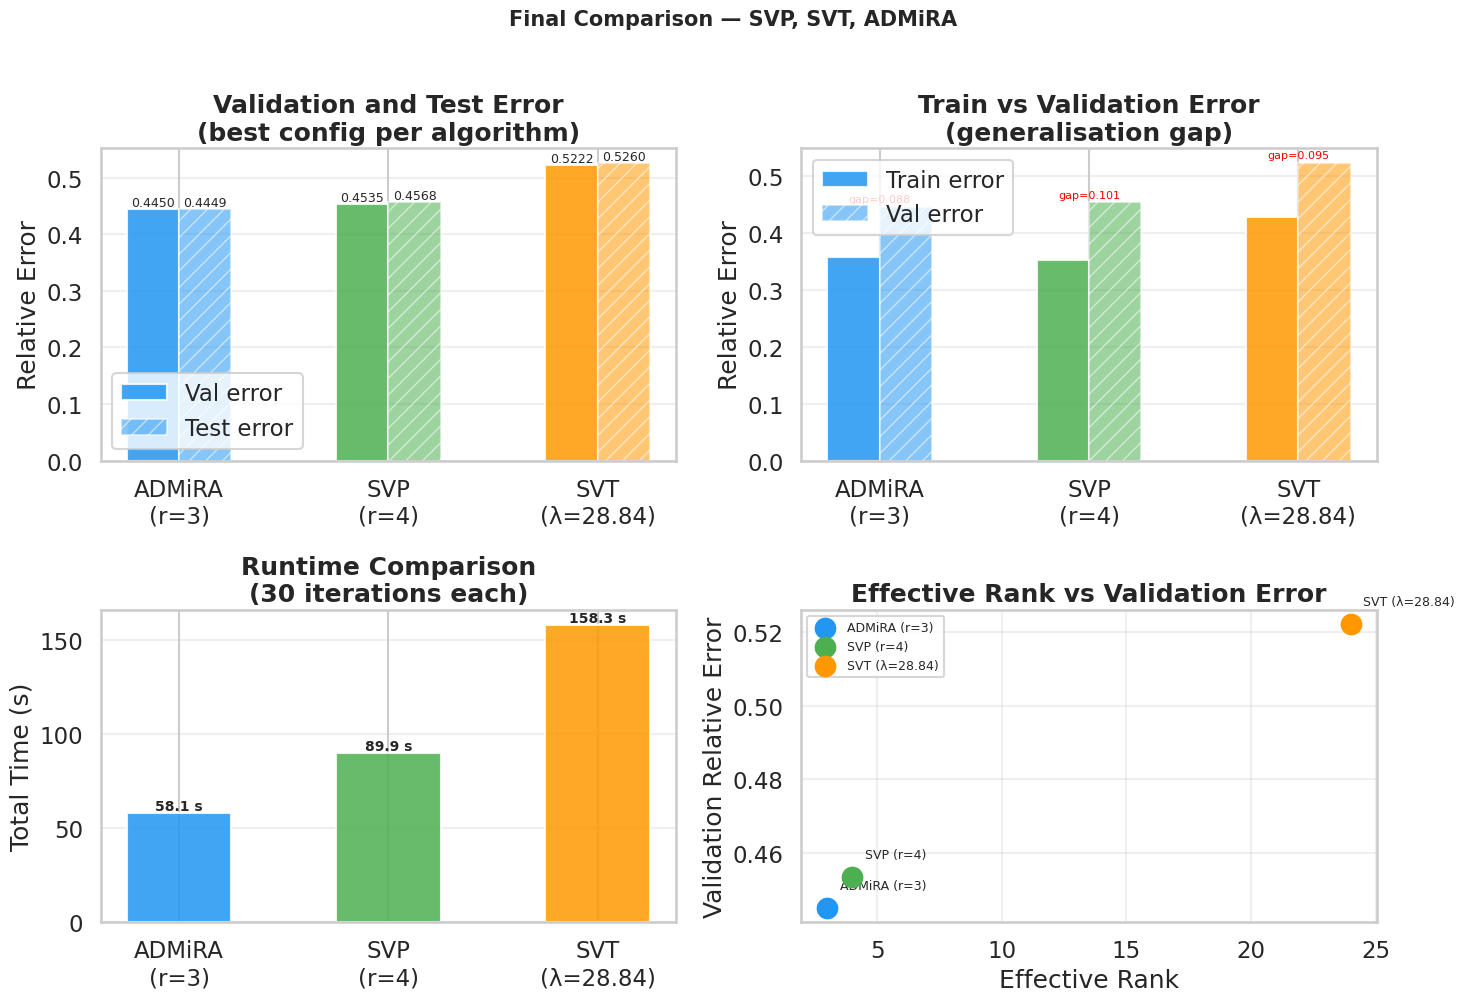

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data from best configurations ────────────────────────────────────────────
algorithms  = ['ADMiRA\n(r=3)', 'SVP\n(r=4)', 'SVT\n(λ=28.84)']
err_val     = [0.4450, 0.4535, 0.5222]
err_test    = [0.4449, 0.4568, 0.5260]
err_train   = [0.3567, 0.3528, 0.4268]
rmse_val    = [1.6283, 1.6594, None]   # SVT RMSE not tracked
runtimes    = [58.1,   89.9,   158.3]
eff_ranks   = [3,      4,      24]

colors = ['#2196F3', '#4CAF50', '#FF9800']  # blue, green, orange
x = np.arange(len(algorithms))
w = 0.25

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Final Comparison — SVP, SVT, ADMiRA', fontsize=15,
             fontweight='bold', y=1.01)

# ── Plot 1: Validation and test error ────────────────────────────────────────
axes[0, 0].bar(x - w/2, err_val,  w, label='Val error',  alpha=0.85, color=colors)
axes[0, 0].bar(x + w/2, err_test, w, label='Test error',
               alpha=0.55, color=colors, hatch='//')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(algorithms)
axes[0, 0].set_ylabel('Relative Error')
axes[0, 0].set_title('Validation and Test Error\n(best config per algorithm)',
                      fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')
# Annotate bars
for i, (v, t) in enumerate(zip(err_val, err_test)):
    axes[0, 0].text(i - w/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)
    axes[0, 0].text(i + w/2, t + 0.005, f'{t:.4f}', ha='center', fontsize=9)

# ── Plot 2: Train vs val error (overfitting diagnostic) ──────────────────────
axes[0, 1].bar(x - w/2, err_train, w, label='Train error', alpha=0.85, color=colors)
axes[0, 1].bar(x + w/2, err_val,   w, label='Val error',
               alpha=0.55, color=colors, hatch='//')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(algorithms)
axes[0, 1].set_ylabel('Relative Error')
axes[0, 1].set_title('Train vs Validation Error\n(generalisation gap)',
                      fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, axis='y')
for i, (tr, v) in enumerate(zip(err_train, err_val)):
    gap = v - tr
    axes[0, 1].text(i, max(tr, v) + 0.008, f'gap={gap:.3f}',
                    ha='center', fontsize=8, color='red')

# ── Plot 3: Runtime comparison ───────────────────────────────────────────────
bars = axes[1, 0].bar(x, runtimes, width=0.5, alpha=0.85, color=colors)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(algorithms)
axes[1, 0].set_ylabel('Total Time (s)')
axes[1, 0].set_title('Runtime Comparison\n(30 iterations each)', fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')
for bar, t in zip(bars, runtimes):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                    f'{t:.1f} s', ha='center', fontsize=10, fontweight='bold')

# ── Plot 4: Effective rank vs validation error (scatter) ─────────────────────
for i, (alg, r, ev) in enumerate(zip(algorithms, eff_ranks, err_val)):
    axes[1, 1].scatter(r, ev, s=200, color=colors[i], zorder=5,
                       label=alg.replace('\n', ' '))
    axes[1, 1].annotate(alg.replace('\n', ' '),
                         xy=(r, ev), xytext=(r + 0.5, ev + 0.005),
                         fontsize=9)

axes[1, 1].set_xlabel('Effective Rank')
axes[1, 1].set_ylabel('Validation Relative Error')
axes[1, 1].set_title('Effective Rank vs Validation Error', fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final Results and Discussion — Comparison of SVP, SVT, and ADMiRA

All algorithms are evaluated on the **same fixed train/validation/test split** (60/20/20)
and with the same primary metric, computed **only on observed entries**:
$$
\mathrm{err}(X,Y)=\frac{\lVert X^S-Y^S\rVert_F}{\lVert Y^S\rVert_F}.
$$
RMSE is reported as a supplementary interpretability metric.
All runs use a cap of **30 iterations**.

---

## Best configurations within the tested grids

### SVP — rank-constrained projection
Tested $r\in\{2,3,4,5\}$, optimal at $r=4$:
$$
\mathrm{err}_{\text{val}}=0.4535,\qquad
\mathrm{err}_{\text{test}}=0.4568,\qquad
\mathrm{RMSE}_{\text{val}}=1.6594,\qquad
t=89.9\,\text{s}.
$$

### SVT — nuclear-norm regularisation
Tested $\lambda\in\{19.95,23.99,28.84,34.67,41.69,50.12\}$, optimal at $\lambda=28.84$:
$$
\mathrm{err}_{\text{val}}=0.5222,\qquad
\mathrm{err}_{\text{test}}=0.5260,\qquad
\mathrm{rank}_{\text{eff}}=24,\qquad
t=158.3\,\text{s}.
$$

### ADMiRA — greedy atom selection
Tested $r\in\{3,5,8,10,12\}$, optimal at $r=3$:
$$
\mathrm{err}_{\text{val}}=0.4450,\qquad
\mathrm{err}_{\text{test}}=0.4449,\qquad
\mathrm{RMSE}_{\text{val}}=1.6283,\qquad
t=58.1\,\text{s}.
$$

---

## Head-to-head comparison

| Algorithm | Best setting      | $\mathrm{err}_{\text{val}}$ | $\mathrm{err}_{\text{test}}$ | $\mathrm{RMSE}_{\text{val}}$ | Time (s) | Rank          |
|-----------|------------------:|----------------------------:|-----------------------------:|-----------------------------:|---------:|---------------|
| **SVP**   | $r=4$             | **0.4535**                  | **0.4568**                   | **1.6594**                   | 89.9     | 4 (fixed)     |
| ADMiRA    | $r=3$             | 0.4450                      | 0.4449                       | 1.6283                       | **58.1** | 3 (fixed)     |
| SVT       | $\lambda=28.84$   | 0.5222                      | 0.5260                       | —                            | 158.3    | 24 (adaptive) |

---

## Key takeaways

### 1. ADMiRA achieves the best validation error and is the fastest
ADMiRA with $r=3$ achieves the lowest validation and test errors among all three
algorithms, while also being the fastest (58.1 s). The greedy atom-selection strategy
is both effective and computationally efficient at low rank.

### 2. SVP is competitive and well-balanced
SVP at $r=4$ is close to ADMiRA in accuracy (err_val 0.4535 vs 0.4450) and runs in
89.9 s. The hard rank constraint is a natural fit for this dataset, where a small number
of singular directions captures most of the predictive structure.

### 3. SVT underperforms despite adaptive rank selection
SVT yields the highest validation error (0.5222) and the longest runtime (158.3 s).
Its main weakness here is **slow convergence**: at 30 iterations the algorithm has not
yet converged, and the repeated full SVD makes each iteration expensive regardless of
effective rank. The convex formulation and automatic rank selection are theoretically
attractive, but insufficient iterations limit practical performance.

### 4. Moderate rank suffices across all algorithms
The optimal effective rank is consistently low: $r=4$ for SVP, $r=3$ for ADMiRA,
and $\mathrm{rank}_{\text{eff}}=24$ for SVT. This is consistent with the singular
value analysis: the spectrum of $Y^S$ decays slowly but the dominant predictive
structure is concentrated in very few components.

### 5. Runtime summary
$$
t_{\text{ADMiRA}} = 58.1\,\text{s}
\;<\;
t_{\text{SVP}} = 89.9\,\text{s}
\;<\;
t_{\text{SVT}} = 158.3\,\text{s}.
$$

---

## Limitations

- **Metric on observed entries only:** all errors are computed on $S$, i.e. on entries
  seen during training. A proper evaluation would measure reconstruction on held-out,
  unobserved entries — which is the actual goal of matrix completion.
- **Iteration cap:** all algorithms are stopped at 30 iterations and have not fully
  converged, particularly SVT. More iterations would likely improve all results.
- **Narrow hyperparameter grids:** the tested ranks and $\lambda$ values cover a
  limited range; a wider or finer search could identify better configurations.
- **No baseline:** a simple user/movie mean-bias model would provide a useful reference
  to assess whether low-rank structure genuinely helps beyond trivial predictors.

---

## Conclusion

Within the tested configurations, **ADMiRA with $r=3$** achieves the best predictive
performance and the lowest runtime, making it the most effective choice on this dataset.
**SVP** is a close second with slightly higher error but comparable efficiency.
**SVT** provides strong theoretical guarantees and automatic rank selection, but its
slow convergence and high per-iteration cost make it less competitive in this setting.

Overall, the results confirm that **a very low effective rank suffices for good
generalisation** on the MovieLens dataset, and that increasing model complexity beyond
this point fits noise rather than predictive structure.